In [73]:
import numpy as np
import matplotlib.pyplot as plt
from pyquaternion import Quaternion
import pickle
import cv2  # Only if you want to display images, not needed for plotting dots only

# Load one image for visualization
img_path = "/home/draiman/Desktop/datasets/nuscenes/samples/CAM_FRONT/n008-2018-05-21-11-06-59-0400__CAM_FRONT__1526915243012465.jpg"   # <-- Set to actual path!
img = plt.imread(img_path)  # Or use cv2.imread + cv2.cvtColor for BGR->RGB
img_h, img_w = img.shape[:2]


In [74]:
# Load calibration from .pkl
with open("/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl", "rb") as f:
    data = pickle.load(f)
infos = data['infos']
sample = infos[0]   # Choose the sample you want to visualize

cam_name = 'CAM_FRONT'
cam_info = sample['cams'][cam_name]

K = np.array(cam_info['cam_intrinsic'])  # 3x3
R = Quaternion(cam_info['sensor2ego_rotation']).rotation_matrix
T = np.array(cam_info['sensor2ego_translation'])


In [75]:
# BEV grid definition (meters, nuScenes convention: x-forward, y-left, z-up)
x_min, x_max, cell_x = 0.0, 50.0, 0.4
y_min, y_max, cell_y = -25.0, 25.0, 0.25
z_bev = 0.0

x_vals = np.arange(x_min, x_max, cell_x)
y_vals = np.arange(y_min, y_max, cell_y)
X, Y = np.meshgrid(x_vals, y_vals, indexing='ij')  # [Hx, Wy]
Z = np.full_like(X, z_bev)
pts_bev = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)  # [N, 3]


In [76]:
# Ego to camera transform: X_cam = R.T @ (X_ego - T)
R_e2c = R.T
T_e2c = -R_e2c @ T
X_ego = pts_bev.T
X_cam = R_e2c @ X_ego + T_e2c[:, None]

# Keep only points in front of the camera
valid = X_cam[2, :] > 0
pts_cam = X_cam[:, valid]

# Project to image pixels
uv_hom = K @ pts_cam
uv = uv_hom[:2, :] / uv_hom[2:3, :]  # [2, N]
u = uv[0]
v = uv[1]

# Points inside image bounds
in_img = (u >= 0) & (u < img_w) & (v >= 0) & (v < img_h)
u_final = u[in_img]
v_final = v[in_img]


In [53]:
import glob

lidar_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar"
all_lidar_files = sorted(glob.glob(f"{lidar_dir}/*.pt"))
print(f"Found {len(all_lidar_files)} LiDAR feature files.")
print("Example files:", all_lidar_files[:3])

# Pick one file for testing
lidar_feat_path = all_lidar_files[0]  # or another index you want
print("Using LiDAR BEV feature file:", lidar_feat_path)


Found 1982 LiDAR feature files.
Example files: ['/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/000681a060c04755a1537cf83b53ba57.pt', '/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/000868a72138448191b4092f75ed7776.pt', '/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/005d3e821c4e4e0ab03f1ea1dcbf9cc8.pt']
Using LiDAR BEV feature file: /home/draiman/Desktop/Datasets_nuscenes/validation/lidar/000681a060c04755a1537cf83b53ba57.pt


In [54]:
import torch

lidar_feat_path = '/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/000681a060c04755a1537cf83b53ba57.pt'
d = torch.load(lidar_feat_path, map_location='cpu')
lidar_feat = d['feat']  # [B, C, H, W] or [C, H, W]
if lidar_feat.ndim == 3:
    lidar_feat = lidar_feat.unsqueeze(0)
B, C, H_bev, W_bev = lidar_feat.shape
print("LiDAR BEV shape:", lidar_feat.shape)


LiDAR BEV shape: torch.Size([1, 256, 90, 90])


In [55]:
# Usually from CenterPoint config
pc_range = [-54, -54, -5, 54, 54, 3]   # [x_min, y_min, z_min, x_max, y_max, z_max]
x_min, y_min, _, x_max, y_max, _ = pc_range

bev_x = np.linspace(x_min, x_max, H_bev, endpoint=False)  # [H_bev]
bev_y = np.linspace(y_min, y_max, W_bev, endpoint=False)  # [W_bev]
X_bev, Y_bev = np.meshgrid(bev_x, bev_y, indexing='ij')   # [H_bev, W_bev]


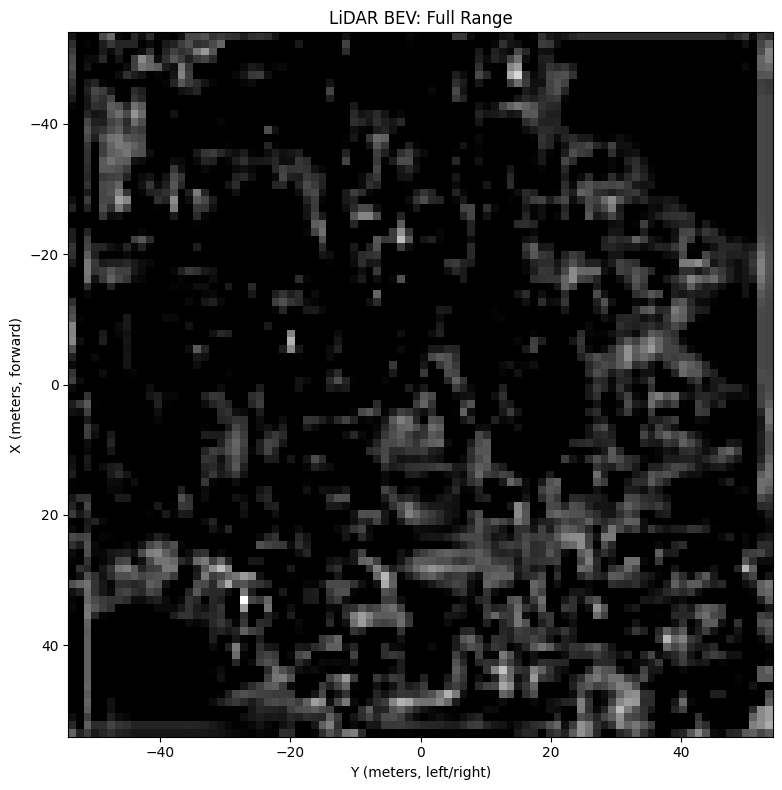

In [56]:
import matplotlib.pyplot as plt

bev_img = lidar_feat[0, 0].cpu().numpy()  # show first channel, or sum for all

plt.figure(figsize=(8,8))
plt.imshow(bev_img, cmap='gray', extent=[y_min, y_max, x_max, x_min])
plt.xlabel("Y (meters, left/right)")
plt.ylabel("X (meters, forward)")
plt.title("LiDAR BEV: Full Range")
plt.tight_layout()
plt.show()


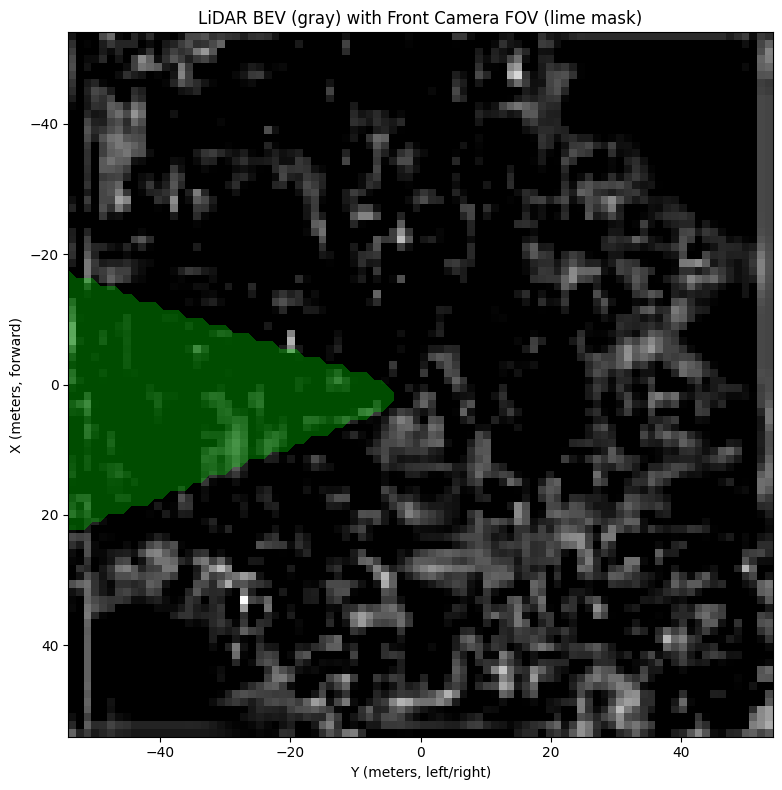

In [57]:
from pyquaternion import Quaternion
import numpy as np

# ----- Camera Calibration: UPDATE these with your real values! -----
K = np.array([
    [1266.4172, 0, 816.2670],
    [0, 1266.4172, 491.5070],
    [0, 0, 1]
])
# Quaternion [w, x, y, z] and translation [x, y, z]
q = [0.5, 0.5, -0.5, 0.5]  # <-- REPLACE with your actual sensor2ego_rotation
R = Quaternion(q).rotation_matrix
T = np.array([1.7, 0.02, 1.51])  # <-- REPLACE with your actual sensor2ego_translation

img_w, img_h = 1600, 928
z_bev = -1.5  # road height

# ---- For each BEV cell, project (x, y, z_bev) into the camera ----
grid_x = X_bev  # [H, W]
grid_y = Y_bev  # [H, W]
grid_z = np.full_like(grid_x, z_bev)  # [H, W]
pts_bev = np.stack([grid_x, grid_y, grid_z], axis=-1).reshape(-1, 3)  # [N, 3]

# Ego -> camera:  X_cam = R.T @ (X_ego - T)
R_e2c = R.T
T_e2c = -R_e2c @ T
X_ego = pts_bev.T
X_cam = R_e2c @ X_ego + T_e2c[:, None]  # [3, N]

# Keep only points in front of camera
valid = X_cam[2, :] > 0
pts_cam = X_cam[:, valid]

# Project to image
uv_hom = K @ pts_cam
uv = uv_hom[:2, :] / uv_hom[2:3, :]
u = uv[0]
v = uv[1]
in_img = (u >= 0) & (u < img_w) & (v >= 0) & (v < img_h)

# Build mask of BEV cells visible in this camera
cam_mask = np.zeros(grid_x.size, dtype=bool)
cam_mask[np.where(valid)[0][in_img]] = True
cam_mask = cam_mask.reshape(grid_x.shape)  # [H, W]

# ---- Overlay on BEV plot ----
plt.figure(figsize=(8,8))
plt.imshow(bev_img, cmap='gray', extent=[y_min, y_max, x_max, x_min])
plt.contourf(Y_bev, X_bev, cam_mask, levels=[0.5, 1], colors='lime', alpha=0.3)
plt.xlabel("Y (meters, left/right)")
plt.ylabel("X (meters, forward)")
plt.title("LiDAR BEV (gray) with Front Camera FOV (lime mask)")
plt.tight_layout()
plt.show()


In [52]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ---- Load LiDAR BEV feature map ----
lidar_feat_path = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar"
d = torch.load(lidar_feat_path, map_location='cpu')
lidar_feat = d['feat']  # shape: [B, C, H, W] or [C, H, W]
if lidar_feat.ndim == 3:
    lidar_feat = lidar_feat.unsqueeze(0)
B, C, H_bev, W_bev = lidar_feat.shape

# ---- LiDAR BEV grid parameters ----
# Use the pc_range and voxel size used to generate your features (from config!)
pc_range = [-54, -54, -5, 54, 54, 3]   # [x_min, y_min, z_min, x_max, y_max, z_max]
x_min, y_min, _, x_max, y_max, _ = pc_range
bev_x = np.linspace(x_min, x_max, H_bev, endpoint=False)  # forward/back
bev_y = np.linspace(y_min, y_max, W_bev, endpoint=False)  # left/right
X, Y = np.meshgrid(bev_x, bev_y, indexing='ij')  # [H_bev, W_bev] each

# ---- Visualize full LiDAR BEV ----
plt.figure(figsize=(8,8))
img = lidar_feat[0, 0].cpu().numpy()
plt.imshow(img, cmap='gray', extent=[y_min, y_max, x_max, x_min])
plt.xlabel("Y (meters, left/right)")
plt.ylabel("X (meters, forward)")
plt.title("LiDAR BEV (no cropping)")

# (Optional) Overlay camera FOV later here
plt.tight_layout()
plt.show()


IsADirectoryError: [Errno 21] Is a directory: '/home/draiman/Desktop/Datasets_nuscenes/validation/lidar'

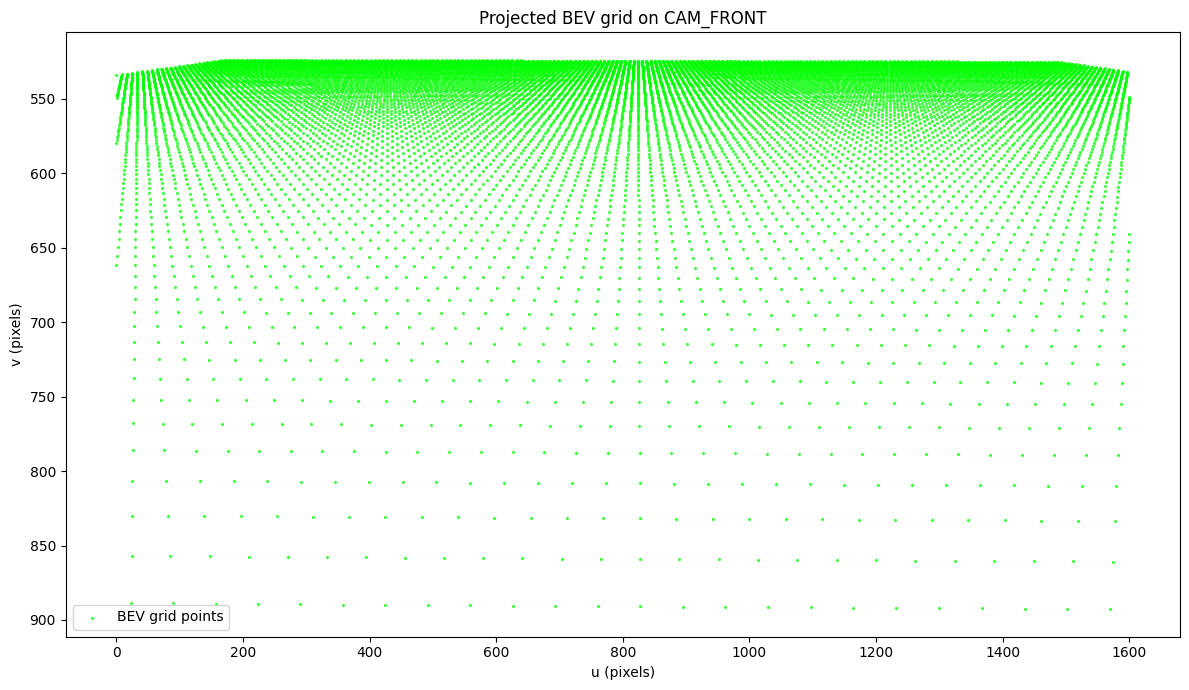

In [83]:
plt.figure(figsize=(12, 7))
# plt.imshow(img)
# plt.scatter(u_final, v_final, s=2, c='lime', alpha=0.6, label='BEV grid points')

plt.scatter(u_final, v_final, s=2, c='lime', alpha=0.6, label='BEV grid points')
plt.gca().invert_yaxis()  # optional — keeps pixel coordinates visually consistent

plt.title(f"Projected BEV grid on {cam_name}")
plt.xlabel("u (pixels)")
plt.ylabel("v (pixels)")
plt.legend()
plt.tight_layout()
plt.show()


In [59]:
# Assume:
#   lidar_feat: [B, C, H, W]
#   cam_mask:   [H, W] boolean, True for cells inside camera FOV

# Mask the LiDAR BEV features (set to zero outside FOV)
lidar_bev_fov = lidar_feat.clone()
lidar_bev_fov[:, :, ~cam_mask] = 0

# Now you can fuse or analyze only BEV cells inside the FOV!


In [60]:
# Find the bounding rectangle of the mask
ys, xs = np.where(cam_mask)
ymin, ymax = ys.min(), ys.max()+1
xmin, xmax = xs.min(), xs.max()+1

lidar_bev_cropped = lidar_bev_fov[:, :, ymin:ymax, xmin:xmax]  # [B, C, H', W']
camera_bev_cropped = camera_bev_fov[:, :, ymin:ymax, xmin:xmax]  # if you have camera BEV features in same grid


NameError: name 'camera_bev_fov' is not defined

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(lidar_bev_fov[0,0], cmap='gray', extent=[y_min, y_max, x_max, x_min])
plt.title("LiDAR BEV Masked to Front Camera FOV")
plt.xlabel("Y (meters, left/right)")
plt.ylabel("X (meters, forward)")
plt.tight_layout()
plt.show()


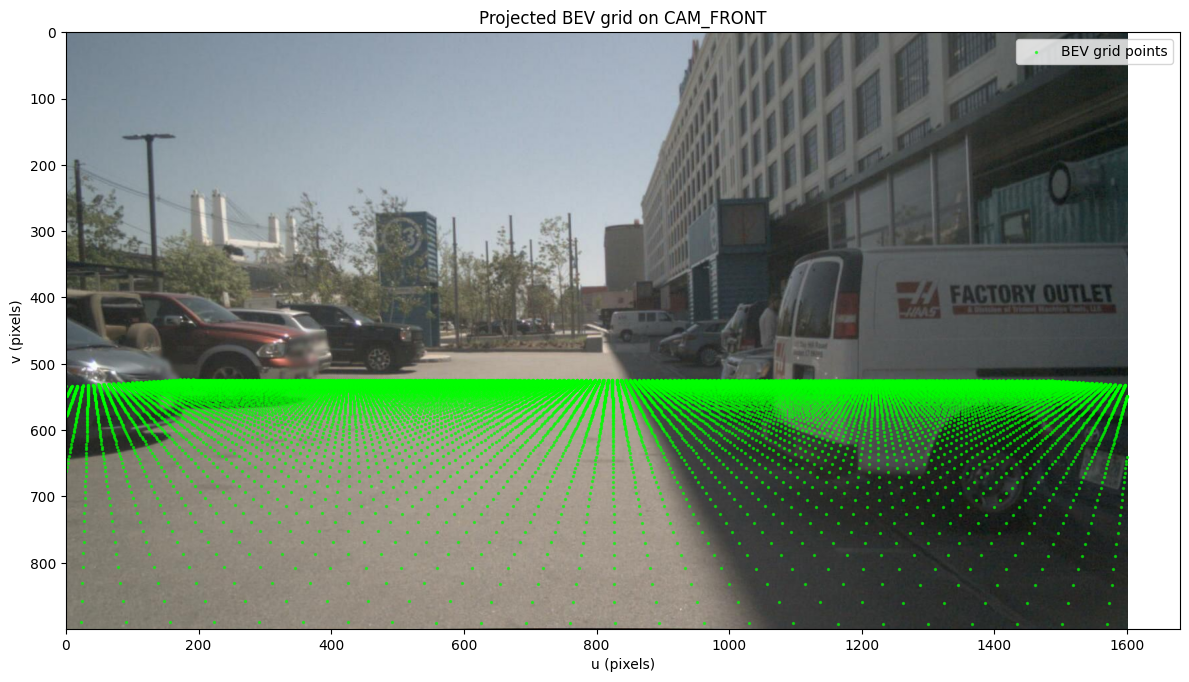

In [84]:

import torch
import os
import glob
import numpy as np


def read_cam_path(camera_root, fpn_level):
        
    camera_files = {
        os.path.splitext(os.path.basename(f))[0].replace(f"_lvl{fpn_level}", ""): f
        for f in glob.glob(os.path.join(camera_root, f"*lvl{fpn_level}.pt"))
    }
    return camera_files

# --- Demo (remove this block if you have real P2) ---
# Dummy P2 to test the printouts:
if __name__ == "__main__":
    
    fpn_level = 0  # 0 = P2, 1 = P3, 2 = P4, 3 = P5 (BEVFormer default: 2 or 3)
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT"

    cam_files = read_cam_path(camera_dir, fpn_level)
    cam_paths = list(cam_files.values())
    for i in range(1):
        cam = torch.load(cam_paths[i], map_location='cpu')
        cam_feat = cam['feat']   
        # print("keys", cam.keys())     # [1,256,H_feat,W_feat] or [256,H_feat,W_feat]
        print("img_shape ", cam['img_shape'])     # [1,256,H_feat,W_feat] or [256,H_feat,W_feat]
        if cam_feat.ndim == 3:
            cam_feat = cam_feat.unsqueeze(0)
        print(f"Sample {i}")
        print(f"  Camera feature shape: {cam_feat.shape}")




    # ---- Step 2: Define BEV grid ----
    # Set BEV spatial coverage and cell size
    cell_x = 0.4    # meters per cell (longitudinal, X/forward)
    cell_y = 0.25   # meters per cell (lateral, Y/sideways)
    x_min, x_max = 0.0, 50.0      # forward: 0 to 50 meters
    y_min, y_max = -25.0, 25.0    # lateral: -25 to +25 meters

    H_bev = int(np.ceil((x_max - x_min) / cell_x))
    W_bev = int(np.ceil((y_max - y_min) / cell_y))
    print(f"BEV grid: {H_bev} x {W_bev} cells  (cell size: {cell_x}m x {cell_y}m)")




    # ---- Step 3: Compute image pixel centers for each P2 cell ----
    B, C, Hf, Wf = cam_feat.shape  # from your loaded P2
    stride_p2 = 4                  # Adjust if your FPN uses a different stride

    # Each P2 cell corresponds to image pixel:
    #   u = (j + 0.5) * stride_p2
    #   v = (i + 0.5) * stride_p2
    j = torch.arange(Wf, dtype=torch.float32) + 0.5
    i = torch.arange(Hf, dtype=torch.float32) + 0.5
    u = j * stride_p2
    v = i * stride_p2

    # Create meshgrid of pixel centers (U: horizontal, V: vertical)
    U, V = torch.meshgrid(u, v, indexing='xy')
    U = U.t().contiguous()  # shape [Hf, Wf]
    V = V.t().contiguous()  # shape [Hf, Wf]

    print(f"U (image x pixel centers): shape {U.shape}, min={U.min().item():.1f}, max={U.max().item():.1f}")
    print(f"V (image y pixel centers): shape {V.shape}, min={V.min().item():.1f}, max={V.max().item():.1f}")


















import pickle
from pyquaternion import Quaternion
import numpy as np

# Load the info file (as in your script)
nuscenes_infos = "/home/draiman/Desktop/datasets/nuscenes"
with open(f"{nuscenes_infos}/nuscenes_infos_temporal_val.pkl", "rb") as f:
    data = pickle.load(f)
infos = data['infos']  # Top key as printed

# Pick a sample (e.g., index 0)
sample = infos[0]

# Pick the camera (e.g., 'CAM_FRONT')
cam_name = 'CAM_FRONT'
cam_info = sample['cams'][cam_name]
# print(f"Inspecting camera: {cam_info.keys()}")
# Camera intrinsics (3x3)
K = np.array(cam_info['cam_intrinsic'])  # 3x3

# Camera-to-ego rotation (quaternion to rotation matrix)
q = cam_info['sensor2ego_rotation']  # [w, x, y, z]
R = Quaternion(q).rotation_matrix    # 3x3

# Camera-to-ego translation
T = np.array(cam_info['sensor2ego_translation'])  # (3,)

print("Intrinsic matrix K:\n", K)
print("Rotation matrix R:\n", R)
print("Translation vector T:\n", T)





import numpy as np
import torch
from pyquaternion import Quaternion

# 1. Assume you have cam_feat [B, C, Hf, Wf] loaded, and K, R, T as before
#    Also, set stride_p2 and BEV grid params

stride_p2 = 4  # or whatever matches your P2
B, C, Hf, Wf = cam_feat.shape

# Unified BEV grid definition (same as before)
x_min, x_max, cell_x = 0.0, 50.0, 0.4
y_min, y_max, cell_y = -25.0, 25.0, 0.25
H_bev = int(np.ceil((x_max - x_min) / cell_x))
W_bev = int(np.ceil((y_max - y_min) / cell_y))
bev_grid = torch.zeros((B, C, H_bev, W_bev), dtype=cam_feat.dtype)

# 2. For each P2 feature cell, compute its (u, v) image pixel center
i = torch.arange(Hf, dtype=torch.float32) + 0.5
j = torch.arange(Wf, dtype=torch.float32) + 0.5
v = i * stride_p2
u = j * stride_p2
U, V = torch.meshgrid(u, v, indexing='xy')
U = U.t().contiguous()  # [Hf, Wf]
V = V.t().contiguous()  # [Hf, Wf]

# 3. Convert image pixel centers (u, v) to 3D rays, then to ground points
#    Assume ground is at z=0, and all pixels "look" forward

# Rebuild camera calibration matrices as numpy arrays
K_np = np.asarray(K)
R_np = np.asarray(R)
T_np = np.asarray(T)

# Prepare inverse intrinsic for backprojection
K_inv = np.linalg.inv(K_np)
all_uv1 = np.stack([U.reshape(-1), V.reshape(-1), np.ones(Hf * Wf)], axis=0)  # [3, N]

# Backproject to camera rays (normalized direction)
rays_cam = K_inv @ all_uv1  # [3, N]
# Assume camera at (0,0,0), rays_cam[:,i] points into scene

# 4. Transform rays to ego (vehicle) coordinates
rays_ego = R_np @ rays_cam  # [3, N]

# 5. Intersect rays with ground plane (z=0), solve for scale s:
#    0 = cam_z + s * dir_z  -->  s = -cam_z / dir_z
cam_height = T_np[2]
s = -cam_height / rays_ego[2, :]
X_ground = T_np[0] + s * rays_ego[0, :]
Y_ground = T_np[1] + s * rays_ego[1, :]
# (Ignore points where rays point up: s <= 0)

# 6. Convert (X_ground, Y_ground) to BEV grid indices
ix = ((X_ground - x_min) / cell_x).astype(np.int64)
iy = ((Y_ground - y_min) / cell_y).astype(np.int64)
valid = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s > 0)

# 7. Accumulate (splat) features into BEV
cam_feat_flat = cam_feat.reshape(B, C, -1)  # [B, C, N]
for b in range(B):
    for n in range(Hf * Wf):
        if valid[n]:
            bev_grid[b, :, ix[n], iy[n]] += cam_feat_flat[b, :, n]

# 8. (Optional) Normalize by count if multiple features hit the same cell

print(f"BEV grid shape: {bev_grid.shape}")


img_shape  [(928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3)]
Sample 0
  Camera feature shape: torch.Size([1, 256, 116, 200])
BEV grid: 125 x 200 cells  (cell size: 0.4m x 0.25m)
U (image x pixel centers): shape torch.Size([200, 116]), min=2.0, max=798.0
V (image y pixel centers): shape torch.Size([200, 116]), min=2.0, max=462.0
Intrinsic matrix K:
 [[1.26641720e+03 0.00000000e+00 8.16267020e+02]
 [0.00000000e+00 1.26641720e+03 4.91507066e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Rotation matrix R:
 [[ 5.68477868e-03 -5.63666773e-03  9.99967955e-01]
 [-9.99983517e-01 -8.37115272e-04  5.68014846e-03]
 [ 8.05071338e-04 -9.99983763e-01 -5.64133364e-03]]
Translation vector T:
 [1.70079119 0.01594563 1.51095764]
BEV grid shape: torch.Size([1, 256, 125, 200])


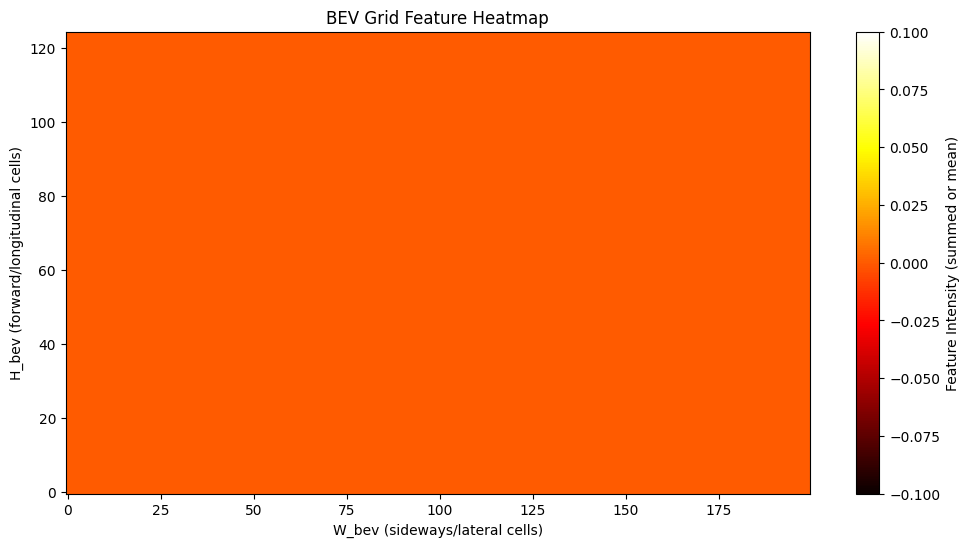

In [86]:
import matplotlib.pyplot as plt
import torch

# Suppose your BEV grid is named bev_grid, shape: [B, C, H_bev, W_bev]
# If you followed your previous code, it's likely [1, 256, 125, 200]

# Remove batch dimension (if present)
bev_img = bev_grid[0]  # shape: [C, H_bev, W_bev]

# Collapse feature channels: sum or mean
# bev_heat = bev_img.sum(dim=0)   # shape: [H_bev, W_bev]
# OR for mean:
bev_heat = bev_img.mean(dim=0)

# Optional: Normalize for display (0 to 1)
bev_heat = bev_heat.cpu().numpy()
bev_heat = (bev_heat - bev_heat.min()) / (bev_heat.max() - bev_heat.min() + 1e-8)

plt.figure(figsize=(12, 6))
plt.imshow(bev_heat, cmap='hot', aspect='auto', origin='lower')
plt.colorbar(label="Feature Intensity (summed or mean)")
plt.title("BEV Grid Feature Heatmap")
plt.xlabel("W_bev (sideways/lateral cells)")
plt.ylabel("H_bev (forward/longitudinal cells)")
plt.show()


In [87]:
print("BEV sum: ", bev_img.sum().item())
print("BEV min: ", bev_img.min().item(), "max:", bev_img.max().item())
print("BEV unique values: ", torch.unique(bev_img))


BEV sum:  0.0
BEV min:  0.0 max: 0.0
BEV unique values:  tensor([0.])


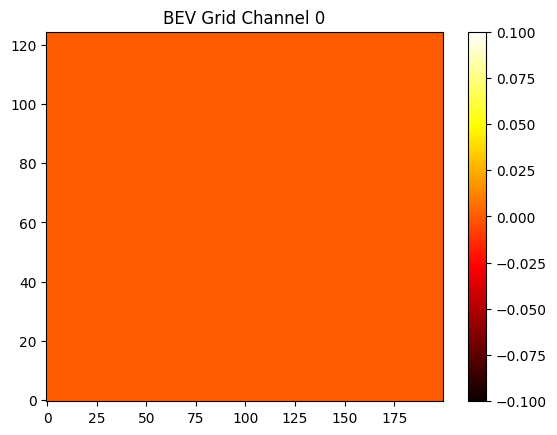

In [92]:
plt.imshow(bev_img[200].cpu().numpy(), cmap='hot', aspect='auto', origin='lower')
plt.title("BEV Grid Channel 0")
plt.colorbar()
plt.show()


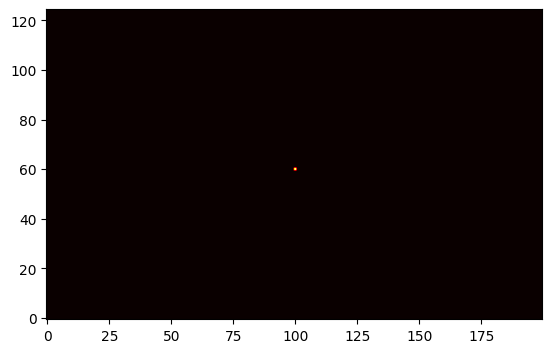

In [93]:
bev_img[:, 60, 100] = 10  # set one cell in the middle to a high value
bev_heat = bev_img.sum(dim=0)
plt.imshow(bev_heat, cmap='hot', origin='lower')
plt.show()


In [109]:
import numpy as np
import matplotlib.pyplot as plt

# BEV grid limits (same as your code)
x_min, x_max, cell_x = 0.0, 50.0, 0.4
y_min, y_max, cell_y = -25.0, 25.0, 0.25

# Create grid points
xs = np.arange(x_min, x_max, cell_x)
ys = np.arange(y_min, y_max, cell_y)
xx, yy = np.meshgrid(xs, ys, indexing='xy')  # shape: [W, H]
N = xx.size

# Flatten to N x 3 (z=0, on ground)
points_bev = np.stack([xx.ravel(), yy.ravel(), np.zeros(N)], axis=1)  # [N, 3]
# Homogeneous coords for projection
points_bev_h = np.concatenate([points_bev, np.ones((N, 1))], axis=1).T  # [4, N]


In [110]:
# lidar2img: shape [3,4] or [4,4] (from your .pt file or info dict)
# Make sure to use the correct one for your camera/sample!
lidar2img = ...  # e.g., cam['lidar2img'].numpy()  or from info['cams']['CAM_FRONT']

# Project points
pts_img = lidar2img @ points_bev_h  # [3, N]
u = pts_img[0, :] / (pts_img[2, :] + 1e-6)  # x in image
v = pts_img[1, :] / (pts_img[2, :] + 1e-6)  # y in image

# Mask: only points that are in front of camera and inside the image
img_w, img_h = 1600, 900   # set to your camera resolution!
mask = (
    (pts_img[2, :] > 0) &
    (u >= 0) & (u < img_w) &
    (v >= 0) & (v < img_h)
)


ValueError: matmul: Input operand 0 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

In [98]:
plt.figure(figsize=(10,6))
# (Optional) Show the camera image background:
# img = plt.imread('path/to/image.jpg')
# plt.imshow(img)
plt.scatter(u[mask], v[mask], s=2, c='red', alpha=0.5)
plt.xlim([0, img_w])
plt.ylim([img_h, 0])  # Invert y-axis for image coordinates
plt.title("BEV Grid Points Projected Into Camera Image")
plt.xlabel("u (image x)")
plt.ylabel("v (image y)")
plt.show()


NameError: name 'mask' is not defined

<Figure size 1000x600 with 0 Axes>

In [105]:
import torch

# Path to your FPN feature file (make sure it matches your sample & level)
file_path = '/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT/0a0d6b8c2e884134a3b48df43d54c36a_lvl0.pt'
data = torch.load(file_path, map_location='cpu')

# This is a torch.Tensor of shape [4,4]
lidar2img = data['lidar2img'].numpy()
lidar2img = lidar2img[:3, :]   # Take only first 3 rows for projection
print("lidar2img: ", lidar2img) 

lidar2img:  [[ 1.2438423e+03  8.3933295e+02  3.4135414e+01 -5.6522412e+02]
 [-1.6580772e+01  5.3725500e+02 -1.2253605e+03 -7.5806171e+02]
 [-1.0701623e-02  9.9846351e-01  5.4369532e-02 -6.7568439e-01]]


In [117]:

import torch

# Path to your FPN feature file (make sure it matches your sample & level)
file_path = '/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT/0d2ebc600fc449f6b7a95f1f69ee52d1_lvl0.pt'
data = torch.load(file_path, map_location='cpu')

# This is a torch.Tensor of shape [4,4]
lidar2img = data['lidar2img'].numpy()
lidar2img = lidar2img[:3, :]   # Take only first 3 rows for projection
print("data: ", data.keys()) 
print("lidar2img: ", lidar2img) 


data:  dict_keys(['feat', 'lidar2img', 'img_shape', 'level', 'cam_name', 'sample_idx'])
lidar2img:  [[ 1.2436943e+03  8.3956262e+02  3.3876476e+01 -3.1477026e+02]
 [-1.6793690e+01  5.3704614e+02 -1.2254492e+03 -6.0971021e+02]
 [-1.0876292e-02  9.9847072e-01  5.4202829e-02 -3.7856233e-01]]


In [107]:
import pickle
import numpy as np

with open('/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl', 'rb') as f:
    data = pickle.load(f)
infos = data['infos']
sample = infos[0]  # or whichever sample you want

cam_info = sample['cams']['CAM_FRONT']
print("cam_info ", cam_info)

cam_info  {'data_path': '/data/nuscenes/samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg', 'type': 'CAM_FRONT', 'sample_data_token': 'b8fba7d78cf547b996c431dec1f5ee26', 'sensor2ego_translation': [1.70079118954, 0.0159456324149, 1.51095763913], 'sensor2ego_rotation': [0.4998015430569128, -0.5030316162024876, 0.4997798114386805, -0.49737083824542755], 'ego2global_translation': [249.90018228466124, 917.5514452794962, 0.0], 'ego2global_rotation': [0.9984397071954904, -0.008652973321832425, 0.002523596051210081, -0.05510815376190409], 'timestamp': 1533201470412460, 'sensor2lidar_rotation': array([[ 0.99996937,  0.0067556 , -0.0039516 ],
       [ 0.00382456,  0.01871645,  0.99981752],
       [ 0.00682833, -0.99980201,  0.01869004]]), 'sensor2lidar_translation': array([-0.01271581,  0.76880558, -0.31059456]), 'cam_intrinsic': array([[1.26641720e+03, 0.00000000e+00, 8.16267020e+02],
       [0.00000000e+00, 1.26641720e+03, 4.91507066e+02],
       [0.00000000e+00,

In [108]:
import numpy as np
from scipy.spatial.transform import Rotation as R

# Suppose cam_info is the dictionary you posted (with numpy arrays for rotations/translations, etc.)
# We'll use sensor2lidar_rotation (3x3), sensor2lidar_translation (3,), cam_intrinsic (3x3)

R_cl = cam_info['sensor2lidar_rotation']        # camera-to-lidar rotation, shape (3, 3)
t_cl = cam_info['sensor2lidar_translation']     # camera-to-lidar translation, shape (3,)
K = cam_info['cam_intrinsic']                   # camera intrinsic, shape (3, 3)

# 1. Invert camera-to-lidar to get lidar-to-camera
R_lc = R_cl.T                   # invert rotation
t_lc = -R_cl.T @ t_cl           # invert translation

# 2. Compose 4x4 lidar-to-camera matrix
lidar2cam = np.eye(4)
lidar2cam[:3, :3] = R_lc
lidar2cam[:3, 3] = t_lc

# 3. Project with intrinsics to get (3, 4) lidar2img
lidar2img = K @ lidar2cam[:3, :]

print("lidar2img matrix:\n", lidar2img)


lidar2img matrix:
 [[ 1.26315285e+03  8.20961550e+02  2.39035795e+01 -6.07673494e+02]
 [ 6.61316935e+00  5.15120214e+02 -1.25698017e+03 -7.86354408e+02]
 [-3.95160255e-03  9.99817517e-01  1.86900441e-02 -7.62910510e-01]]


In [122]:
import pickle
nuscenes_infos_path = "/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl"
with open(nuscenes_infos_path, "rb") as f:
    infos_data = pickle.load(f)
infos = infos_data['infos']

In [123]:
def find_cam_info_by_sample_data_token(infos, cam_name, sample_data_token):
    for sample in infos:
        cam_info = sample['cams'][cam_name]
        if cam_info['sample_data_token'] == sample_data_token:
            return cam_info, sample
    raise ValueError(f"No sample with {cam_name} and data_token {sample_data_token} found.")

In [127]:
import os

# Given your feature file:
feature_path = '/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT/0d2ebc600fc449f6b7a95f1f69ee52d1_lvl0.pt'

# Extract the token
basename = os.path.basename(feature_path)
# Handles both ..._[lvl0.pt], ..._IvI0.pt, etc.
parts = basename.split('_')
sample_data_token = parts[0]

cam_name = 'CAM_FRONT'
cam_info, sample = find_cam_info_by_sample_data_token(infos, cam_name, sample_data_token)


ValueError: No sample with CAM_FRONT and data_token 0d2ebc600fc449f6b7a95f1f69ee52d1 found.

In [144]:
print("Keys in infos[0]:", infos[0].keys())
print("Keys in infos[0]['cams']:", infos[0]['cams'].keys())

Keys in infos[0]: dict_keys(['lidar_path', 'token', 'prev', 'next', 'can_bus', 'frame_idx', 'sweeps', 'cams', 'scene_token', 'lidar2ego_translation', 'lidar2ego_rotation', 'ego2global_translation', 'ego2global_rotation', 'timestamp', 'gt_boxes', 'gt_names', 'gt_velocity', 'num_lidar_pts', 'num_radar_pts', 'valid_flag'])
Keys in infos[0]['cams']: dict_keys(['CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_FRONT_LEFT', 'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT'])


In [145]:
def find_cam_info_by_sample_data_token(infos, cam_name, sample_data_token):
    print(f"Looking for cam_name={cam_name}, sample_data_token={sample_data_token}")
    for i, sample in enumerate(infos):
        if cam_name not in sample['cams']:
            print(f"[{i}] {cam_name} not in sample['cams'] keys: {sample['cams'].keys()}")
            continue
        cam_info = sample['cams'][cam_name]
        current_token = cam_info['sample_data_token']
        if current_token == sample_data_token:
            print(f"Match found at index {i}")
            return cam_info, sample
        else:
            # Print occasionally to avoid too much spam
            if i % 50 == 0:
                print(f"[{i}] No match. Current token: {current_token}")
    raise ValueError(f"No sample with {cam_name} and data_token {sample_data_token} found.")


In [150]:
import os

# Given your feature file:
feature_path = '/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT/0d2ebc600fc449f6b7a95f1f69ee52d1_lvl0.pt'

# Extract the token
basename = os.path.basename(feature_path)
# Handles both ..._[lvl0.pt], ..._IvI0.pt, etc.
parts = basename.split('_')
sample_data_token = parts[0]
print("sample_data_token", sample_data_token)
# cam_name = 'CAM_FRONT'
# cam_info, sample = find_cam_info_by_sample_data_token(infos, cam_name, sample_data_token)

sample_data_token 0d2ebc600fc449f6b7a95f1f69ee52d1


In [149]:
print("Extracted token:", sample_data_token)
print("Example token from infos[0]['cams']['CAM_FRONT']:", infos[0]['cams']['CAM_FRONT']['sample_data_token'])
parts = basename.split('_')
print(parts)


Extracted token: 0d2ebc600fc449f6b7a95f1f69ee52d1
Example token from infos[0]['cams']['CAM_FRONT']: b8fba7d78cf547b996c431dec1f5ee26
['0d2ebc600fc449f6b7a95f1f69ee52d1', 'lvl0.pt']


In [135]:
found = False
for sample in infos:
    for cam, cam_info in sample['cams'].items():
        if sample_data_token in cam_info['sample_data_token']:
            print(f"Partial match found in {cam}: {cam_info['sample_data_token']}")
            found = True
if not found:
    print("No partial matches found — check token formatting.")


No partial matches found — check token formatting.


In [151]:
for i in range(5):
    print(f"Sample {i}: {infos[i]['cams']['CAM_FRONT']['sample_data_token']}")

Sample 0: b8fba7d78cf547b996c431dec1f5ee26
Sample 1: 85628360e4574730b17c77686d7ddda1
Sample 2: 6db5cabec0054eab9583bf86c7040f67
Sample 3: d475bfdda0dc4994ad22265771494d5d
Sample 4: be7cd73c9175438484c96f8eb72ea586


In [166]:
import pickle
nuscenes_infos_path = "/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl"
with open(nuscenes_infos_path, "rb") as f:
    infos_data = pickle.load(f)
infos = infos_data['infos']


print(f"Total samples: {len(infos)}")

for i in range(len(infos)):
    print(f"Sample {i}: {infos[i]['cams']['CAM_FRONT']['sample_data_token']}")


In [154]:
camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT"




In [161]:
import os
import pickle
# Path to your directory
camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT"
nuscenes_infos_path = "/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl"

with open(nuscenes_infos_path, "rb") as f:
    infos_data = pickle.load(f)
infos = infos_data['infos']

# Get list of all tokens from your data
sample_tokens = [info['cams']['CAM_FRONT']['sample_data_token'] for info in infos]

# Get all file tokens in your folder (removing the .pt extension)
file_tokens = [f[:-3] for f in os.listdir(camera_dir) if f.endswith('.pt')]

# Find the intersection (which tokens from infos exist as files)
matched = [token for token in sample_tokens if token in file_tokens]

print(f"Found {len(matched)} matching samples out of {len(sample_tokens)}")


Found 0 matching samples out of 1982


In [160]:
print("First sample token:", sample_tokens[0])
print("First file token:", file_tokens[0])


First sample token: b8fba7d78cf547b996c431dec1f5ee26
First file token: 1223445bb2b14ecda09c2b8149e0ec77


In [164]:
import os
import pickle
# Path to your directory
camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT"
nuscenes_infos_path = "/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl"

with open(nuscenes_infos_path, "rb") as f:
    infos_data = pickle.load(f)
infos = infos_data['infos']

# Get list of all tokens from your data
sample_tokens = [info['cams']['CAM_FRONT']['sample_data_token'] for info in infos]

# Get all file tokens in your folder (removing the .pt extension)
file_tokens = [f[:-3] for f in os.listdir(camera_dir) if f.endswith('.pt')]

# Find the intersection (which tokens from infos exist as files)
matched = [token for token in sample_tokens if token in file_tokens]

print(f"Found {len(matched)} matching samples out of {len(sample_tokens)}")


Found 0 matching samples out of 1982


In [165]:
# Assuming sample_tokens is your list
unique_tokens = set(sample_tokens)
print(f"Total tokens: {len(sample_tokens)}")
print(f"Unique tokens: {len(unique_tokens)}")

if len(sample_tokens) == len(unique_tokens):
    print("All sample tokens are unique.")
else:
    print("There are duplicate tokens!")


Total tokens: 1982
Unique tokens: 1982
All sample tokens are unique.


In [170]:
import json

# Path to your sample_data.json
sample_data_json_path = "/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json"

with open(sample_data_json_path, 'r') as f:
    sample_data = json.load(f)

# Create a mapping: token -> filename
token_to_filename = {entry['token']: entry['filename'] for entry in sample_data}

In [171]:
# Example: Check for first 5 tokens in infos
for i in range(5):
    token = infos[i]['cams']['CAM_FRONT']['sample_data_token']
    filename = token_to_filename.get(token, None)
    print(f"Sample {i}: token = {token}, filename = {filename}")


Sample 0: token = b8fba7d78cf547b996c431dec1f5ee26, filename = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg
Sample 1: token = 85628360e4574730b17c77686d7ddda1, filename = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470912460.jpg
Sample 2: token = 6db5cabec0054eab9583bf86c7040f67, filename = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201471412477.jpg
Sample 3: token = d475bfdda0dc4994ad22265771494d5d, filename = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201471912460.jpg
Sample 4: token = be7cd73c9175438484c96f8eb72ea586, filename = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201472412460.jpg


In [172]:
import os

nusc_root = "/path/to/nuscenes/v1.0-trainval/"  # adjust as needed

for i in range(5):
    token = infos[i]['cams']['CAM_FRONT']['sample_data_token']
    filename = token_to_filename.get(token, None)
    if filename:
        full_path = os.path.join(nusc_root, filename)
        exists = os.path.exists(full_path)
    else:
        exists = False
    print(f"Sample {i}: token = {token}, file = {filename}, exists = {exists}")


Sample 0: token = b8fba7d78cf547b996c431dec1f5ee26, file = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg, exists = False
Sample 1: token = 85628360e4574730b17c77686d7ddda1, file = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470912460.jpg, exists = False
Sample 2: token = 6db5cabec0054eab9583bf86c7040f67, file = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201471412477.jpg, exists = False
Sample 3: token = d475bfdda0dc4994ad22265771494d5d, file = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201471912460.jpg, exists = False
Sample 4: token = be7cd73c9175438484c96f8eb72ea586, file = samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201472412460.jpg, exists = False


In [173]:
token = infos[0]['cams']['CAM_FRONT']['sample_data_token']
entry = next((item for item in sample_data if item['token'] == token), None)
print(json.dumps(entry, indent=2))


{
  "token": "b8fba7d78cf547b996c431dec1f5ee26",
  "sample_token": "fd8420396768425eabec9bdddf7e64b6",
  "ego_pose_token": "b8fba7d78cf547b996c431dec1f5ee26",
  "calibrated_sensor_token": "774231675dc44f2792896d731c8709ff",
  "timestamp": 1533201470412460,
  "fileformat": "jpg",
  "is_key_frame": true,
  "height": 900,
  "width": 1600,
  "filename": "samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg",
  "prev": "",
  "next": "891a5802c274466c96e33955e8943d2d"
}


In [ ]:
token = infos[0]['cams']['CAM_FRONT']['sample']
entry = next((item for item in sample_data if item['token'] == token), None)
print(json.dumps(entry, indent=2))


In [175]:
pt_filename = "b8fba7d78cf547b996c431dec1f5ee26.pt"
pt_token = os.path.splitext(pt_filename)[0]  # removes '.pt'
matching_entries = []
for i, info in enumerate(infos):
    token = info['cams']['CAM_FRONT']['sample_data_token']
    if token == pt_token:
        matching_entries.append((i, info))

index = None
for i, info in enumerate(infos):
    if info['cams']['CAM_FRONT']['sample_data_token'] == pt_token:
        index = i
        break

if index is not None:
    print(f"Found token '{pt_token}' at infos[{index}]")
else:
    print(f"Token '{pt_token}' not found in infos.")




def find_info_index_by_pt_filename(pt_filename, infos):
    pt_token = os.path.splitext(pt_filename)[0]
    for i, info in enumerate(infos):
        if info['cams']['CAM_FRONT']['sample_data_token'] == pt_token:
            return i, info
    return None, None

# Usage
idx, info = find_info_index_by_pt_filename("b8fba7d78cf547b996c431dec1f5ee26.pt", infos)
if idx is not None:
    print(f"Token found at infos[{idx}].")
    # You can print or process info here.
else:
    print("Token not found.")


Found token 'b8fba7d78cf547b996c431dec1f5ee26' at infos[0]
Token found at infos[0].


In [183]:
import json

# Path to your sample_data.json
sample_data_json_path = "/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json"

with open(sample_data_json_path, 'r') as f:
    sample_data = json.load(f)

# for i in range(1):
#     # print(sample_data)
#     for entry in sample_data:
#         print(entry)
import pprint

for entry in sample_data[:5]:
    pprint.pprint(entry)

{'calibrated_sensor_token': '7781065816974801afc4dcdaf6acf92c',
 'ego_pose_token': 'bddd80ae33ec4e32b27fdb3c1160a30e',
 'fileformat': 'pcd',
 'filename': 'samples/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530440378.pcd',
 'height': 0,
 'is_key_frame': True,
 'next': '90df03ad4710427aabb5f88fe049df2e',
 'prev': '',
 'sample_token': 'e93e98b63d3b40209056d129dc53ceee',
 'timestamp': 1531883530440378,
 'token': 'bddd80ae33ec4e32b27fdb3c1160a30e',
 'width': 0}
{'calibrated_sensor_token': '7781065816974801afc4dcdaf6acf92c',
 'ego_pose_token': '90df03ad4710427aabb5f88fe049df2e',
 'fileformat': 'pcd',
 'filename': 'sweeps/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530510442.pcd',
 'height': 0,
 'is_key_frame': False,
 'next': '28e6129458c745dbbcbdbb3329e91575',
 'prev': 'bddd80ae33ec4e32b27fdb3c1160a30e',
 'sample_token': '14d5adfe50bb4445bc3aa5fe607691a8',
 'timestamp': 1531883530510442,
 'token': '90df03ad4710427aabb5f88fe049df2e',
 'width': 0}
{'cali

SyntaxError: EOL while scanning string literal (2824423885.py, line 1)

In [186]:
import os
import json
import pickle
import pprint

# File paths
pt_file = "/home/draiman/Desktop/Datasets_nuscenes/validation/resnet/CAM_FRONT/0afa886817744d61be66f0bcea2be47c.pt"
sample_data_json_path = "/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json"
pkl_path = "/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl"



# Step 1: Extract token from .pt file
pt_token = os.path.splitext(os.path.basename(pt_file))[0]

# Step 2: Load sample_data.json and find entry
with open(sample_data_json_path, 'r') as f:
    sample_data = json.load(f)
sample_entry = next((item for item in sample_data if item['token'] == pt_token), None)

print("\n--- sample_data.json entry ---")
if sample_entry:
    pprint.pprint(sample_entry)
else:
    print(f"Token {pt_token} not found in sample_data.json.")

# Step 3: If found, get sample_token
if sample_entry:
    sample_token = sample_entry['sample_token']

    # Step 4: Load .pkl and search for matching info
    with open(pkl_path, 'rb') as f:
        infos = pickle.load(f)

    # Try to find by CAM_FRONT's sample_data_token
    pkl_entry = None
    for info in infos:
        cam_token = info.get('cams', {}).get('CAM_FRONT', {}).get('sample_data_token')
        if cam_token == pt_token:
            pkl_entry = info
            break

    print("\n--- .pkl (info) entry ---")
    if pkl_entry:
        pprint.pprint(pkl_entry)
    else:
        print(f"No entry in .pkl found with CAM_FRONT sample_data_token = {pt_token}")

else:
    print("Skipping .pkl lookup since token not found in sample_data.json.")


--- sample_data.json entry ---
Token 0afa886817744d61be66f0bcea2be47c not found in sample_data.json.
Skipping .pkl lookup since token not found in sample_data.json.


In [187]:
import json

sample_data_json_path = "/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json"
pt_token = "0afa886817744d61be66f0bcea2be47c"

with open(sample_data_json_path, 'r') as f:
    sample_data = json.load(f)

matches = []
for entry in sample_data:
    if pt_token in entry['filename'] or pt_token == entry['token']:
        matches.append(entry)

if matches:
    print("Matches found in sample_data.json:")
    for match in matches:
        print(match)
else:
    print("No matches found by filename or token in sample_data.json.")


No matches found by filename or token in sample_data.json.


In [189]:
import pickle
import pprint

# Your .pkl file path and the token to search for
pkl_path = "/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl"
target_token = "b8fba7d78cf547b996c431dec1f5ee26"

# Load the infos
with open(pkl_path, 'rb') as f:
    infos = pickle.load(f)

# Search for the token in each info's CAM_FRONT sample_data_token
found = False
for info in infos:
    cam_front = info.get('cams', {}).get('CAM_FRONT', {})
    if cam_front.get('sample_data_token') == target_token:
        print("Found entry:")
        pprint.pprint(info)
        found = True
        break

if not found:
    print(f"Token {target_token} not found in .pkl file.")


AttributeError: 'str' object has no attribute 'get'

In [210]:
import pickle

pkl_path = "/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl"

with open(pkl_path, 'rb') as f:
    infos = pickle.load(f)

print(type(infos))
print("First entry:", infos.keys())
# <class 'dict'>
# First entry: dict_keys(['infos', 'metadata'])

print(type(infos['infos'][0]))
print("First entry:", infos['infos'][0].keys())
# <class 'dict'>
# First entry: dict_keys(['lidar_path', 'token', 'prev', 'next', 'can_bus', 'frame_idx', 'sweeps', 'cams', 'scene_token', 'lidar2ego_translation', 'lidar2ego_rotation', 'ego2global_translation', 'ego2global_rotation', 'timestamp', 'gt_boxes', 'gt_names', 'gt_velocity', 'num_lidar_pts', 'num_radar_pts', 'valid_flag'])

print(type(infos['metadata']))
print("Second entry:", infos['metadata'].keys())
# <class 'dict'>
# Second entry: dict_keys(['version'])


<class 'dict'>
Second entry: dict_keys(['version'])


In [213]:
import pickle
import pprint

pkl_path = "/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl"
target_token = "b8fba7d78cf547b996c431dec1f5ee26"

with open(pkl_path, 'rb') as f:
    all_infos = pickle.load(f)

infos = all_infos['infos']  # This is your actual list of samples

found = False
for info in infos:
    cam_front = info.get('cams', {}).get('CAM_FRONT', {})
    if cam_front.get('sample_data_token') == target_token:
        print("Found entry in .pkl (CAM_FRONT sample_data_token matches):")
        pprint.pprint(info['cams']['CAM_FRONT'])
        
        found = True
        break

if not found:
    print(f"Token {target_token} not found as CAM_FRONT sample_data_token in .pkl file.")


Found entry in .pkl (CAM_FRONT sample_data_token matches):
{'cam_intrinsic': array([[1.26641720e+03, 0.00000000e+00, 8.16267020e+02],
       [0.00000000e+00, 1.26641720e+03, 4.91507066e+02],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]]),
 'data_path': '/data/nuscenes/samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg',
 'ego2global_rotation': [0.9984397071954904,
                         -0.008652973321832425,
                         0.002523596051210081,
                         -0.05510815376190409],
 'ego2global_translation': [249.90018228466124, 917.5514452794962, 0.0],
 'sample_data_token': 'b8fba7d78cf547b996c431dec1f5ee26',
 'sensor2ego_rotation': [0.4998015430569128,
                         -0.5030316162024876,
                         0.4997798114386805,
                         -0.49737083824542755],
 'sensor2ego_translation': [1.70079118954, 0.0159456324149, 1.51095763913],
 'sensor2lidar_rotation': array([[ 0.99996937,  0.0067556 

In [214]:
import json
import pprint

sample_data_json_path = "/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json"
target_token = "b8fba7d78cf547b996c431dec1f5ee26"

with open(sample_data_json_path, 'r') as f:
    sample_data = json.load(f)

entry = next((item for item in sample_data if item['token'] == target_token), None)

if entry:
    print("Found entry in sample_data.json:")
    pprint.pprint(entry)
else:
    print(f"Token {target_token} not found in sample_data.json.")


Found entry in sample_data.json:
{'calibrated_sensor_token': '774231675dc44f2792896d731c8709ff',
 'ego_pose_token': 'b8fba7d78cf547b996c431dec1f5ee26',
 'fileformat': 'jpg',
 'filename': 'samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg',
 'height': 900,
 'is_key_frame': True,
 'next': '891a5802c274466c96e33955e8943d2d',
 'prev': '',
 'sample_token': 'fd8420396768425eabec9bdddf7e64b6',
 'timestamp': 1533201470412460,
 'token': 'b8fba7d78cf547b996c431dec1f5ee26',
 'width': 1600}


SyntaxError: invalid syntax (241969691.py, line 2)

In [221]:
target_token = "fd8420396768425eabec9bdddf7e64b6" # from the saved features  

In [223]:
import json
import pprint

sample_data_json_path = "/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json"

with open(sample_data_json_path, 'r') as f:
    sample_data = json.load(f)

entry = next((item for item in sample_data if item['sample_token'] == target_token), None)


# entry = next((item for item in sample_data if item['token'] == target_token), None)

if entry:
    print("Found entry in sample_data.json:")
    pprint.pprint(entry)
else:
    print(f"Token {target_token} not found in sample_data.json.")


Found entry in sample_data.json:
{'calibrated_sensor_token': '019b4307d3ac46659069ba0075d83a70',
 'ego_pose_token': 'a80ee7369c9a4a15946caa5d59155bf2',
 'fileformat': 'pcd',
 'filename': 'samples/RADAR_FRONT/n015-2018-08-02-17-16-37+0800__RADAR_FRONT__1533201470471993.pcd',
 'height': 0,
 'is_key_frame': True,
 'next': '54e903c245af414b889105bf32724332',
 'prev': '',
 'sample_token': 'fd8420396768425eabec9bdddf7e64b6',
 'timestamp': 1533201470471993,
 'token': 'a80ee7369c9a4a15946caa5d59155bf2',
 'width': 0}



The CAM_FRONT entry for sample_token fd8420396768425eabec9bdddf7e64b6:
{'calibrated_sensor_token': '774231675dc44f2792896d731c8709ff',
 'ego_pose_token': 'b8fba7d78cf547b996c431dec1f5ee26',
 'fileformat': 'jpg',
 'filename': 'samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg',
 'height': 900,
 'is_key_frame': True,
 'next': '891a5802c274466c96e33955e8943d2d',
 'prev': '',
 'sample_token': 'fd8420396768425eabec9bdddf7e64b6',
 'timestamp': 1533201470412460,
 'token': 'b8fba7d78cf547b996c431dec1f5ee26',
 'width': 1600}

Its token is: b8fba7d78cf547b996c431dec1f5ee26


In [1]:
import json
import pprint

sample_data_json_path = "/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json"
target_sample_token = "fd8420396768425eabec9bdddf7e64b6"
desired_camera = "CAM_FRONT"  # Or any other camera name

with open(sample_data_json_path, 'r') as f:
    sample_data = json.load(f)

# Find all entries matching this sample_token
matching_entries = [entry for entry in sample_data if entry['sample_token'] == target_sample_token]

# Print all found entries
# print(f"\nAll entries for sample_token {target_sample_token}:")
# for entry in matching_entries:
#     pprint.pprint(entry)

# Now, find the entry for the desired camera
desired_entry = None
for entry in matching_entries:
    if desired_camera in entry['filename']:
        desired_entry = entry
        break

if desired_entry:
    print(f"\nThe {desired_camera} entry for sample_token {target_sample_token}:")
    pprint.pprint(desired_entry)
    print(f"\nIts token is: {desired_entry['token']}")
else:
    print(f"No {desired_camera} entry found for sample_token {target_sample_token}.")



The CAM_FRONT entry for sample_token fd8420396768425eabec9bdddf7e64b6:
{'calibrated_sensor_token': '774231675dc44f2792896d731c8709ff',
 'ego_pose_token': 'b8fba7d78cf547b996c431dec1f5ee26',
 'fileformat': 'jpg',
 'filename': 'samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg',
 'height': 900,
 'is_key_frame': True,
 'next': '891a5802c274466c96e33955e8943d2d',
 'prev': '',
 'sample_token': 'fd8420396768425eabec9bdddf7e64b6',
 'timestamp': 1533201470412460,
 'token': 'b8fba7d78cf547b996c431dec1f5ee26',
 'width': 1600}

Its token is: b8fba7d78cf547b996c431dec1f5ee26


In [9]:
import pickle
import numpy as np

import pickle
from pyquaternion import Quaternion
import numpy as np
target_token = desired_entry['token'] # example 'b8fba7d78cf547b996c431dec1f5ee26'


with open("/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl", "rb") as f:
    data = pickle.load(f)
infos = data['infos']

found = False
for idx, sample in enumerate(infos):
    cam_info = sample['cams']['CAM_FRONT']
    if cam_info['sample_data_token'] == target_token:
        print(f"Found at infos[{idx}]:")
        print(sample['cams']['CAM_FRONT'])
        found = True
        break

if not found:
    print(f"Token {target_token} not found in CAM_FRONT sample_data_token.")



cam_info = sample['cams']['CAM_FRONT']

KKK = np.array(cam_info['cam_intrinsic'])  # 3x3
RRR = Quaternion(cam_info['sensor2ego_rotation']).rotation_matrix
TTT = np.array(cam_info['sensor2ego_translation'])

print("Camera Intrinsic (K):\n", KKK)
print("Camera->ego rotation (RRR):\n", RRR)
print("Camera->ego translation (TTT):\n", TTT)


Found at infos[0]:
{'data_path': '/data/nuscenes/samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg', 'type': 'CAM_FRONT', 'sample_data_token': 'b8fba7d78cf547b996c431dec1f5ee26', 'sensor2ego_translation': [1.70079118954, 0.0159456324149, 1.51095763913], 'sensor2ego_rotation': [0.4998015430569128, -0.5030316162024876, 0.4997798114386805, -0.49737083824542755], 'ego2global_translation': [249.90018228466124, 917.5514452794962, 0.0], 'ego2global_rotation': [0.9984397071954904, -0.008652973321832425, 0.002523596051210081, -0.05510815376190409], 'timestamp': 1533201470412460, 'sensor2lidar_rotation': array([[ 0.99996937,  0.0067556 , -0.0039516 ],
       [ 0.00382456,  0.01871645,  0.99981752],
       [ 0.00682833, -0.99980201,  0.01869004]]), 'sensor2lidar_translation': array([-0.01271581,  0.76880558, -0.31059456]), 'cam_intrinsic': array([[1.26641720e+03, 0.00000000e+00, 8.16267020e+02],
       [0.00000000e+00, 1.26641720e+03, 4.91507066e+02],
       [0.0000

In [5]:
# # BEV grid definition (meters, nuScenes convention: x-forward, y-left, z-up)
# x_min, x_max, cell_x = 0.0, 50.0, 0.4
# y_min, y_max, cell_y = -25.0, 25.0, 0.25
# z_bev = 0.0

# x_vals = np.arange(x_min, x_max, cell_x)
# y_vals = np.arange(y_min, y_max, cell_y)
# X, Y = np.meshgrid(x_vals, y_vals, indexing='ij')  # [Hx, Wy]
# Z = np.full_like(X, z_bev)
# pts_bev = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)  # [N, 3]

# # Ego to camera transform: X_cam = R.T @ (X_ego - T)
# R_e2c = R.T
# T_e2c = -R_e2c @ T
# X_ego = pts_bev.T
# X_cam = R_e2c @ X_ego + T_e2c[:, None]

# # Keep only points in front of the camera
# valid = X_cam[2, :] > 0
# pts_cam = X_cam[:, valid]

# # Project to image pixels
# uv_hom = K @ pts_cam
# uv = uv_hom[:2, :] / uv_hom[2:3, :]  # [2, N]
# u = uv[0]
# v = uv[1]

# # Points inside image bounds
# in_img = (u >= 0) & (u < img_w) & (v >= 0) & (v < img_h)
# u_final = u[in_img]
# v_final = v[in_img]


In [ ]:


# plt.figure(figsize=(12, 7))
# # plt.imshow(img)
# # plt.scatter(u_final, v_final, s=2, c='lime', alpha=0.6, label='BEV grid points')

# plt.scatter(u_final, v_final, s=2, c='lime', alpha=0.6, label='BEV grid points')
# plt.gca().invert_yaxis()  # optional — keeps pixel coordinates visually consistent

# plt.title(f"Projected BEV grid on {cam_name}")
# plt.xlabel("u (pixels)")
# plt.ylabel("v (pixels)")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [16]:
import torch
import os

def load_specific_cam_file(camera_dir, target_sample_token, fpn_level):
    # Compose the expected filename
    filename = f"{target_sample_token}_lvl{fpn_level}.pt"
    file_path = os.path.join(camera_dir, filename)
    return file_path

# --- Demo (replace with your real code as needed) ---
if __name__ == "__main__":
    fpn_level = 0
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT"
    # target_token = 'fd8420396768425eabec9bdddf7e64b6'
    target_sample_token = 'fd8420396768425eabec9bdddf7e64b6'
    
    # Build file name and path
    cam_path = load_specific_cam_file(camera_dir, target_sample_token, fpn_level)
    print("Chosen file path:", cam_path)

    # Load and process the file
    cam = torch.load(cam_path, map_location='cpu')
    cam_feat = cam['feat']
    print("img_shape ", cam['img_shape'])
    if cam_feat.ndim == 3:
        cam_feat = cam_feat.unsqueeze(0)
    print("Camera feature shape:", cam_feat.shape)


Chosen file path: /home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT/fd8420396768425eabec9bdddf7e64b6_lvl0.pt
img_shape  [(928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3)]
Camera feature shape: torch.Size([1, 256, 116, 200])


In [10]:
# testing 



import torch
import os
import glob
import numpy as np

import pickle
from pyquaternion import Quaternion
import numpy as np


# --- Demo (remove this block if you have real P2) ---
# Dummy P2 to test the printouts:
if __name__ == "__main__":


    # ---- Step 2: Define BEV grid ----
    # Set BEV spatial coverage and cell size
    cell_x = 0.4    # meters per cell (longitudinal, X/forward)
    cell_y = 0.25   # meters per cell (lateral, Y/sideways)
    x_min, x_max = 0.0, 50.0      # forward: 0 to 50 meters
    y_min, y_max = -25.0, 25.0    # lateral: -25 to +25 meters

    H_bev = int(np.ceil((x_max - x_min) / cell_x))
    W_bev = int(np.ceil((y_max - y_min) / cell_y))
    print(f"BEV grid: {H_bev} x {W_bev} cells  (cell size: {cell_x}m x {cell_y}m)")




    # ---- Step 3: Compute image pixel centers for each P2 cell ----
    B, C, Hf, Wf = cam_feat.shape  # from your loaded P2
    stride_p2 = 4                  # Adjust if your FPN uses a different stride

    # Each P2 cell corresponds to image pixel:
    #   u = (j + 0.5) * stride_p2
    #   v = (i + 0.5) * stride_p2
    # j = torch.arange(Wf, dtype=torch.float32) + 0.5
    # i = torch.arange(Hf, dtype=torch.float32) + 0.5
    # u = j * stride_p2
    # v = i * stride_p2

    # # Create meshgrid of pixel centers (U: horizontal, V: vertical)
    # U, V = torch.meshgrid(u, v, indexing='xy')
    # U = U.t().contiguous()  # shape [Hf, Wf]
    # V = V.t().contiguous()  # shape [Hf, Wf]

    # print(f"U (image x pixel centers): shape {U.shape}, min={U.min().item():.1f}, max={U.max().item():.1f}")
    # print(f"V (image y pixel centers): shape {V.shape}, min={V.min().item():.1f}, max={V.max().item():.1f}")




    
    # Pick a center pixel index in feature space
    center_j = Wf // 2
    center_i = Hf // 2
    u_c = (center_j + 0.5) * stride_p2
    v_c = (center_i + 0.5) * stride_p2
    uv1 = np.array([u_c, v_c, 1.0])
    
    # Camera ray in pixel coords
    ray_cam = np.linalg.inv(KKK) @ uv1
    
    # Ray in ego coordinates
    ray_ego = RRR @ ray_cam
    
    # Camera center in ego frame
    cam_center_ego = TTT
    
    # Intersection with z=0 plane in ego frame
    cam_z = cam_center_ego[2]
    dir_z = ray_ego[2]
    if dir_z == 0:
        print("Warning, direction z=0")
    else:
        s = -cam_z / dir_z
        X_ground = cam_center_ego[0] + s * ray_ego[0]
        Y_ground = cam_center_ego[1] + s * ray_ego[1]
        print(f"Center pixel ground intersection: X={X_ground:.2f}  Y={Y_ground:.2f} (should be in front of vehicle)")


BEV grid: 125 x 200 cells  (cell size: 0.4m x 0.25m)
Center pixel ground intersection: X=-5.95  Y=-2.53 (should be in front of vehicle)


In [11]:
# new 
# ... after your current setup:
center_j = Wf // 2
center_i = Hf // 2
u_c = (center_j + 0.5) * stride_p2
v_c = (center_i + 0.5) * stride_p2
uv1 = np.array([u_c, v_c, 1.0])
ray_cam = np.linalg.inv(KKK) @ uv1

# TRY RRR.T INSTEAD OF RRR
ray_ego = RRR.T @ ray_cam
cam_center_ego = TTT
cam_z = cam_center_ego[2]
dir_z = ray_ego[2]
s = -cam_z / dir_z
X_ground = cam_center_ego[0] + s * ray_ego[0]
Y_ground = cam_center_ego[1] + s * ray_ego[1]
print(f"Center pixel ground intersection (RRR.T): X={X_ground:.2f}, Y={Y_ground:.2f}")


Center pixel ground intersection (RRR.T): X=2.62, Y=-4.50


In [7]:

# import torch
# import os
# import glob
# import numpy as np

# import pickle
# from pyquaternion import Quaternion
# import numpy as np


# # --- Demo (remove this block if you have real P2) ---
# # Dummy P2 to test the printouts:
# if __name__ == "__main__":


#     # ---- Step 2: Define BEV grid ----
#     # Set BEV spatial coverage and cell size
#     cell_x = 0.4    # meters per cell (longitudinal, X/forward)
#     cell_y = 0.25   # meters per cell (lateral, Y/sideways)
#     x_min, x_max = 0.0, 50.0      # forward: 0 to 50 meters
#     y_min, y_max = -25.0, 25.0    # lateral: -25 to +25 meters

#     H_bev = int(np.ceil((x_max - x_min) / cell_x))
#     W_bev = int(np.ceil((y_max - y_min) / cell_y))
#     print(f"BEV grid: {H_bev} x {W_bev} cells  (cell size: {cell_x}m x {cell_y}m)")




#     # ---- Step 3: Compute image pixel centers for each P2 cell ----
#     B, C, Hf, Wf = cam_feat.shape  # from your loaded P2
#     stride_p2 = 4                  # Adjust if your FPN uses a different stride

#     # Each P2 cell corresponds to image pixel:
#     #   u = (j + 0.5) * stride_p2
#     #   v = (i + 0.5) * stride_p2
#     j = torch.arange(Wf, dtype=torch.float32) + 0.5
#     i = torch.arange(Hf, dtype=torch.float32) + 0.5
#     u = j * stride_p2
#     v = i * stride_p2

#     # Create meshgrid of pixel centers (U: horizontal, V: vertical)
#     U, V = torch.meshgrid(u, v, indexing='xy')
#     U = U.t().contiguous()  # shape [Hf, Wf]
#     V = V.t().contiguous()  # shape [Hf, Wf]

#     print(f"U (image x pixel centers): shape {U.shape}, min={U.min().item():.1f}, max={U.max().item():.1f}")
#     print(f"V (image y pixel centers): shape {V.shape}, min={V.min().item():.1f}, max={V.max().item():.1f}")



















# # # Load the info file (as in your script)
# # nuscenes_infos = "/home/draiman/Desktop/datasets/nuscenes"
# # with open(f"{nuscenes_infos}/nuscenes_infos_temporal_val.pkl", "rb") as f:
# #     data = pickle.load(f)
# # infos = data['infos']  # Top key as printed

# # # Pick a sample (e.g., index 0)
# # sample = infos[0]

# # # Pick the camera (e.g., 'CAM_FRONT')
# # cam_name = 'CAM_FRONT'
# # cam_info = sample['cams'][cam_name]
# # # print(f"Inspecting camera: {cam_info.keys()}")
# # # Camera intrinsics (3x3)
# # K = np.array(cam_info['cam_intrinsic'])  # 3x3

# # # Camera-to-ego rotation (quaternion to rotation matrix)
# # q = cam_info['sensor2ego_rotation']  # [w, x, y, z]
# # R = Quaternion(q).rotation_matrix    # 3x3

# # # Camera-to-ego translation
# # T = np.array(cam_info['sensor2ego_translation'])  # (3,)

# # print("Intrinsic matrix K:\n", K)
# # print("Rotation matrix R:\n", R)
# # print("Translation vector T:\n", T)





# import numpy as np
# import torch
# from pyquaternion import Quaternion

# # 1. Assume you have cam_feat [B, C, Hf, Wf] loaded, and K, R, T as before
# #    Also, set stride_p2 and BEV grid params

# stride_p2 = 4  # or whatever matches your P2
# B, C, Hf, Wf = cam_feat.shape

# # Unified BEV grid definition (same as before)
# x_min, x_max, cell_x = 0.0, 50.0, 0.4
# y_min, y_max, cell_y = -25.0, 25.0, 0.25
# H_bev = int(np.ceil((x_max - x_min) / cell_x))
# W_bev = int(np.ceil((y_max - y_min) / cell_y))
# bev_grid = torch.zeros((B, C, H_bev, W_bev), dtype=cam_feat.dtype)

# # 2. For each P2 feature cell, compute its (u, v) image pixel center
# i = torch.arange(Hf, dtype=torch.float32) + 0.5
# j = torch.arange(Wf, dtype=torch.float32) + 0.5
# v = i * stride_p2
# u = j * stride_p2
# U, V = torch.meshgrid(u, v, indexing='xy')
# U = U.t().contiguous()  # [Hf, Wf]
# V = V.t().contiguous()  # [Hf, Wf]

# # 3. Convert image pixel centers (u, v) to 3D rays, then to ground points
# #    Assume ground is at z=0, and all pixels "look" forward

# # Rebuild camera calibration matrices as numpy arrays
# K_np = np.asarray(KKK)
# R_np = np.asarray(RRR)
# T_np = np.asarray(TTT)

# # Prepare inverse intrinsic for backprojection
# K_inv = np.linalg.inv(K_np)
# all_uv1 = np.stack([U.reshape(-1), V.reshape(-1), np.ones(Hf * Wf)], axis=0)  # [3, N]

# # Backproject to camera rays (normalized direction)
# rays_cam = K_inv @ all_uv1  # [3, N]
# # Assume camera at (0,0,0), rays_cam[:,i] points into scene

# # 4. Transform rays to ego (vehicle) coordinates
# rays_ego = R_np @ rays_cam  # [3, N]

# # 5. Intersect rays with ground plane (z=0), solve for scale s:
# #    0 = cam_z + s * dir_z  -->  s = -cam_z / dir_z
# cam_height = T_np[2]
# s = -cam_height / rays_ego[2, :]
# X_ground = T_np[0] + s * rays_ego[0, :]
# Y_ground = T_np[1] + s * rays_ego[1, :]
# # (Ignore points where rays point up: s <= 0)
# print("X_ground min/max:", X_ground.min(), X_ground.max())
# print("Y_ground min/max:", Y_ground.min(), Y_ground.max())


# # 6. Convert (X_ground, Y_ground) to BEV grid indices
# ix = ((X_ground - x_min) / cell_x).astype(np.int64)
# iy = ((Y_ground - y_min) / cell_y).astype(np.int64)
# valid = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s > 0)

# # 7. Accumulate (splat) features into BEV
# cam_feat_flat = cam_feat.reshape(B, C, -1)  # [B, C, N]
# for b in range(B):
#     for n in range(Hf * Wf):
#         if valid[n]:
#             bev_grid[b, :, ix[n], iy[n]] += cam_feat_flat[b, :, n]

# # 8. (Optional) Normalize by count if multiple features hit the same cell

# print(f"BEV grid shape: {bev_grid.shape}")


BEV grid: 125 x 200 cells  (cell size: 0.4m x 0.25m)
U (image x pixel centers): shape torch.Size([200, 116]), min=2.0, max=798.0
V (image y pixel centers): shape torch.Size([200, 116]), min=2.0, max=462.0
X_ground min/max: -86.13813418906707 -2.265617648745361
Y_ground min/max: -57.164808190774046 -0.06509338195440813
BEV grid shape: torch.Size([1, 256, 125, 200])


In [31]:
# # === NEW VERSION (replace your whole cell with this) ===
# import torch
# import numpy as np

# # Assumes you already loaded:
# #   cam_feat: [B, C, Hf, Wf]
# #   KKK: 3x3 intrinsics
# #   RRR, TTT: ego->camera rotation (3x3) and translation (3,)  (from NuScenes sensor2ego)
# # If your variables are named differently, just map them accordingly.

# # ---- BEV grid (unchanged) ----
# cell_x = 0.4
# cell_y = 0.25
# x_min, x_max = 0.0, 50.0
# y_min, y_max = -25.0, 25.0

# B, C, Hf, Wf = cam_feat.shape
# H_bev = int(np.ceil((x_max - x_min) / cell_x))
# W_bev = int(np.ceil((y_max - y_min) / cell_y))
# print(f"BEV grid: {H_bev} x {W_bev} cells  (cell size: {cell_x}m x {cell_y}m)")

# bev_grid = torch.zeros((B, C, H_bev, W_bev), dtype=cam_feat.dtype)

# # ---- FIX 1: correct FPN stride for your P2 map ----
# # Your images are 928x1600 and features are 116x200 -> stride = 8
# stride_p2 = 8

# # Image pixel centers for each feature location (shapes: [Hf, Wf])
# i = torch.arange(Hf, dtype=torch.float32) + 0.5
# j = torch.arange(Wf, dtype=torch.float32) + 0.5
# V, U = torch.meshgrid(i * stride_p2, j * stride_p2, indexing='ij')  # V: row(y), U: col(x)
# print(f"U shape {U.shape}, V shape {V.shape}, U[min,max]=({U.min():.1f},{U.max():.1f}), V[min,max]=({V.min():.1f},{V.max():.1f})")

# # ---- Calib to numpy ----
# K = np.asarray(KKK, dtype=np.float64)
# R_ego2cam = np.asarray(RRR, dtype=np.float64)
# t_ego2cam = np.asarray(TTT, dtype=np.float64).reshape(3)

# # ---- FIX 2: use camera->ego transform & camera center in ego ----
# R_cam2ego = R_ego2cam.T
# C_ego = -R_cam2ego @ t_ego2cam   # camera center in ego frame

# # Backproject pixel centers to camera rays
# K_inv = np.linalg.inv(K)
# all_uv1 = np.stack([U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf * Wf)], axis=0)  # [3, N]
# rays_cam = K_inv @ all_uv1                 # [3, N]
# rays_ego = R_cam2ego @ rays_cam            # [3, N]

# # Intersect with ground plane z=0 in ego frame
# cam_z = C_ego[2]
# dir_z = rays_ego[2, :]
# s = -cam_z / (dir_z + 1e-12)               # avoid divide-by-zero
# X_ground = C_ego[0] + s * rays_ego[0, :]
# Y_ground = C_ego[1] + s * rays_ego[1, :]

# print("X_ground min/max:", float(X_ground.min()), float(X_ground.max()))
# print("Y_ground min/max:", float(Y_ground.min()), float(Y_ground.max()))

# # Convert (X,Y) -> BEV indices
# ix = ((X_ground - x_min) / cell_x).astype(np.int64)
# iy = ((Y_ground - y_min) / cell_y).astype(np.int64)
# valid = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s > 0)

# # Splat features into BEV
# cam_feat_flat = cam_feat.reshape(B, C, -1)  # [B, C, Hf*Wf]
# for b in range(B):
#     for n in range(Hf * Wf):
#         if valid[n]:
#             bev_grid[b, :, ix[n], iy[n]] += cam_feat_flat[b, :, n]

# print(f"BEV grid shape: {bev_grid.shape}")
# # === END NEW VERSION ===


BEV grid: 125 x 200 cells  (cell size: 0.4m x 0.25m)
U shape torch.Size([116, 200]), V shape torch.Size([116, 200]), U[min,max]=(4.0,1596.0), V[min,max]=(4.0,924.0)
X_ground min/max: -133.76293126787917 764.7076161220618
Y_ground min/max: -1176.215371352376 2246.788488233865
BEV grid shape: torch.Size([1, 256, 125, 200])


In [38]:
# # most one working ###############################################################################


# # === NEW VERSION (drop-in replacement) ===
# import torch
# import numpy as np

# # Expects already loaded:
# # cam_feat: [B, C, Hf, Wf]
# # KKK: 3x3 intrinsics (for the image size you used to extract features)
# # RRR, TTT: nuScenes sensor2ego (camera->ego) rotation (3x3) and translation (3,)

# # ---- BEV grid (unchanged) ----
# cell_x = 0.4
# cell_y = 0.25
# x_min, x_max = 0.0, 50.0
# y_min, y_max = -25.0, 25.0

# B, C, Hf, Wf = cam_feat.shape
# H_bev = int(np.ceil((x_max - x_min) / cell_x))
# W_bev = int(np.ceil((y_max - y_min) / cell_y))
# print(f"BEV grid: {H_bev} x {W_bev} cells  (cell size: {cell_x}m x {cell_y}m)")

# bev_grid = torch.zeros((B, C, H_bev, W_bev), dtype=cam_feat.dtype)

# # ---- FIX 1: correct FPN stride (P2 is 116x200 from 928x1600 -> stride 8) ----
# stride_p2 = 8

# # Pixel centers per feature location (V=row/y, U=col/x)
# i = torch.arange(Hf, dtype=torch.float32) + 0.5
# j = torch.arange(Wf, dtype=torch.float32) + 0.5
# V, U = torch.meshgrid(i * stride_p2, j * stride_p2, indexing='ij')
# print(f"U shape {U.shape}, V shape {V.shape}, U[min,max]=({U.min():.1f},{U.max():.1f}), V[min,max]=({V.min():.1f},{V.max():.1f})")

# # ---- Intrinsics / Extrinsics ----
# K = np.asarray(KKK, dtype=np.float64).copy()

# # OPTIONAL: if K was for 1600x900 but your resized height is 928, scale fy and cy
# # (Comment these two lines out if KKK already matches 928 height.)
# scale_y = 928.0 / 900.0
# K[1,1] *= scale_y;  K[1,2] *= scale_y

# # nuScenes sensor2ego is camera->ego already
# R_cam2ego = np.asarray(RRR, dtype=np.float64)          # USE AS-IS (no transpose)
# C_ego     = np.asarray(TTT, dtype=np.float64).reshape(3)  # camera center in ego

# # ---- Backproject and intersect ground ----
# K_inv = np.linalg.inv(K)
# all_uv1 = np.stack([U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf*Wf)], axis=0)  # [3, N]
# rays_cam = K_inv @ all_uv1                 # [3, N] directions in camera
# rays_ego = R_cam2ego @ rays_cam            # [3, N] directions in ego

# cam_z = C_ego[2]
# dir_z = rays_ego[2, :]
# s = -cam_z / (dir_z + 1e-12)               # s>0 ⇒ forward intersection
# print(f"% rays with dir_z < 0: {100.0 * (dir_z < 0).mean():.1f}%")
# X_ground = C_ego[0] + s * rays_ego[0, :]
# Y_ground = C_ego[1] + s * rays_ego[1, :]

# print("X_ground min/max:", float(X_ground.min()), float(X_ground.max()))
# print("Y_ground min/max:", float(Y_ground.min()), float(Y_ground.max()))

# # ---- Rasterize into BEV ----
# ix = ((X_ground - x_min) / cell_x).astype(np.int64)
# iy = ((Y_ground - y_min) / cell_y).astype(np.int64)
# valid = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s > 0)

# cam_feat_flat = cam_feat.reshape(B, C, -1)  # [B, C, Hf*Wf]
# hits = 0
# for b in range(B):
#     for n in range(Hf * Wf):
#         if valid[n]:
#             bev_grid[b, :, ix[n], iy[n]] += cam_feat_flat[b, :, n]
#             hits += 1
# print(f"Valid splats: {hits} / {Hf*Wf}")

# print(f"BEV grid shape: {bev_grid.shape}")
# # === END NEW VERSION ===


BEV grid: 125 x 200 cells  (cell size: 0.4m x 0.25m)
U shape torch.Size([116, 200]), V shape torch.Size([116, 200]), U[min,max]=(4.0,1596.0), V[min,max]=(4.0,924.0)
% rays with dir_z < 0: 46.5%
X_ground min/max: -332192.56565915473 2897128.3182324497
Y_ground min/max: -1542919.8179389255 179002.00927219403
Valid splats: 9643 / 23200
BEV grid shape: torch.Size([1, 256, 125, 200])


In [41]:
# === NEW VERSION (drop-in replacement) ===
import torch
import numpy as np

# Expects already loaded:
# cam_feat: [B, C, Hf, Wf]
# KKK: 3x3 intrinsics (for the image size you used to extract features)
# RRR, TTT: nuScenes sensor2ego (camera->ego) rotation (3x3) and translation (3,)

# ---- BEV grid (unchanged) ----
cell_x = 0.4
cell_y = 0.25
x_min, x_max = 0.0, 50.0
y_min, y_max = -25.0, 25.0

B, C, Hf, Wf = cam_feat.shape
H_bev = int(np.ceil((x_max - x_min) / cell_x))
W_bev = int(np.ceil((y_max - y_min) / cell_y))
print(f"BEV grid: {H_bev} x {W_bev} cells  (cell size: {cell_x}m x {cell_y}m)")

bev_grid = torch.zeros((B, C, H_bev, W_bev), dtype=cam_feat.dtype)

# ---- FIX 1: correct FPN stride (P2 is 116x200 from 928x1600 -> stride 8) ----
stride_p2 = 8

# Pixel centers per feature location (V=row/y, U=col/x)
i = torch.arange(Hf, dtype=torch.float32) + 0.5
j = torch.arange(Wf, dtype=torch.float32) + 0.5
V, U = torch.meshgrid(i * stride_p2, j * stride_p2, indexing='ij')
print(f"U shape {U.shape}, V shape {V.shape}, U[min,max]=({U.min():.1f},{U.max():.1f}), V[min,max]=({V.min():.1f},{V.max():.1f})")

# ---- Intrinsics / Extrinsics ----
K = np.asarray(KKK, dtype=np.float64).copy()

# OPTIONAL: if K was for 1600x900 but your resized height is 928, scale fy and cy
# (Comment these two lines out if KKK already matches 928 height.)
scale_y = 928.0 / 900.0
K[1,1] *= scale_y;  K[1,2] *= scale_y

# nuScenes sensor2ego is camera->ego already
# R_cam2ego = np.asarray(RRR, dtype=np.float64)          # USE AS-IS (no transpose)
R_cam2ego = np.asarray(RRR, dtype=np.float64)
C_ego     = np.asarray(TTT, dtype=np.float64).reshape(3)  # camera center in ego

# ---- Backproject and intersect ground ----
K_inv = np.linalg.inv(K)
all_uv1 = np.stack([U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf*Wf)], axis=0)  # [3, N]
rays_cam = K_inv @ all_uv1                 # [3, N] directions in camera
# rays_cam[1:3, :] *= -1   # now y_cam is up; DO NOT flip z
rays_cam[1, :] *= -1    
rays_ego = R_cam2ego @ rays_cam            # [3, N] directions in ego

cam_z = C_ego[2]
dir_z = rays_ego[2, :]
print(f"cam_z: {cam_z:.3f}, dir_z[min,max]: ({dir_z.min():.6f},{dir_z.max():.6f})")
print(f"% rays with dir_z < 0: {100.0 * (dir_z < 0).mean():.1f}%")

valid_down = dir_z < 0
print(f"Downward rays: {valid_down.sum()} / {len(dir_z)} ({100.0 * valid_down.mean():.1f}%)")


s = -cam_z / (dir_z + 1e-12)               # s>0 ⇒ forward intersection
# s= -cam_z / (rays_ego[2, :] + 1e-12)
X_ground = C_ego[0] + s * rays_ego[0, :]
Y_ground = C_ego[1] + s * rays_ego[1, :]

print("X_ground min/max:", float(X_ground.min()), float(X_ground.max()))
print("Y_ground min/max:", float(Y_ground.min()), float(Y_ground.max()))

# ---- Rasterize into BEV ----
ix = ((X_ground - x_min) / cell_x).astype(np.int64)
iy = ((Y_ground - y_min) / cell_y).astype(np.int64)
valid = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s > 0)

cam_feat_flat = cam_feat.reshape(B, C, -1)  # [B, C, Hf*Wf]
hits = 0
for b in range(B):
    for n in range(Hf * Wf):
        if valid[n]:
            bev_grid[b, :, ix[n], iy[n]] += cam_feat_flat[b, :, n]
            hits += 1
print(f"Valid splats: {hits} / {Hf*Wf}")

print(f"BEV grid shape: {bev_grid.shape}")
# === END NEW VERSION ===


BEV grid: 125 x 200 cells  (cell size: 0.4m x 0.25m)
U shape torch.Size([116, 200]), V shape torch.Size([116, 200]), U[min,max]=(4.0,1596.0), V[min,max]=(4.0,924.0)
cam_z: 1.511, dir_z[min,max]: (-0.391197,0.314344)
% rays with dir_z < 0: 55.2%
Downward rays: 12800 / 23200 (55.2%)
X_ground min/max: -1692.0850784955803 360.52581268525125
Y_ground min/max: -1099.9763032671262 484.8962278642961
Valid splats: 11786 / 23200
BEV grid shape: torch.Size([1, 256, 125, 200])


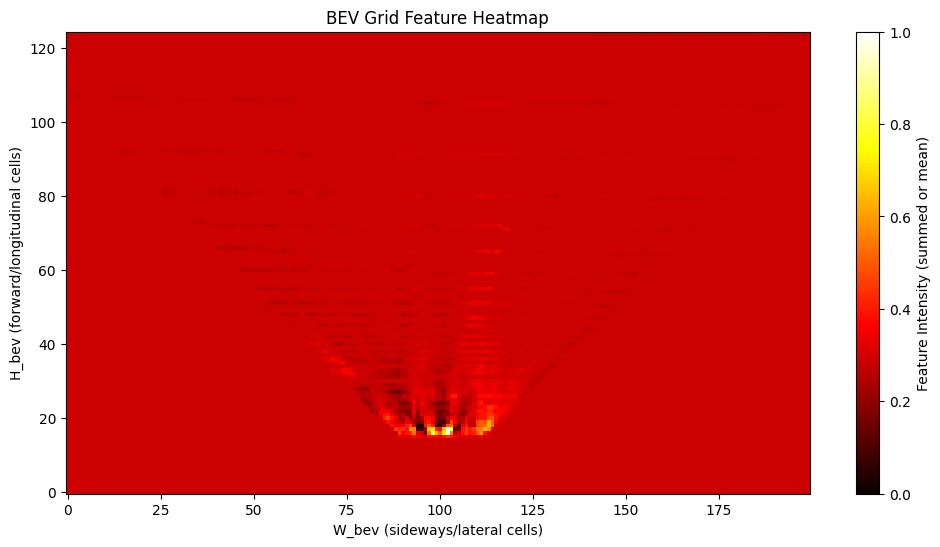

In [39]:
import matplotlib.pyplot as plt
import torch

# Suppose your BEV grid is named bev_grid, shape: [B, C, H_bev, W_bev]
# If you followed your previous code, it's likely [1, 256, 125, 200]

# Remove batch dimension (if present)
bev_img = bev_grid[0]  # shape: [C, H_bev, W_bev]

# Collapse feature channels: sum or mean
# bev_heat = bev_img.sum(dim=0)   # shape: [H_bev, W_bev]
# OR for mean:
bev_heat = bev_img.mean(dim=0)

# Optional: Normalize for display (0 to 1)
bev_heat = bev_heat.cpu().numpy()
bev_heat = (bev_heat - bev_heat.min()) / (bev_heat.max() - bev_heat.min() + 1e-8)

plt.figure(figsize=(12, 6))
plt.imshow(bev_heat, cmap='hot', aspect='auto', origin='lower')
plt.colorbar(label="Feature Intensity (summed or mean)")
plt.title("BEV Grid Feature Heatmap")
plt.xlabel("W_bev (sideways/lateral cells)")
plt.ylabel("H_bev (forward/longitudinal cells)")
plt.show()


In [46]:
# === NEW VERSION (adds Z / 3D voxel grid) ===
import torch
import numpy as np

# Inputs already loaded:
# cam_feat: [B, C, Hf, Wf]
# KKK: 3x3 intrinsics (for the image size used to extract features)
# RRR, TTT: nuScenes sensor2ego (camera->ego) rotation (3x3) and translation (3,)

# -------------- XY BEV grid (unchanged) --------------
cell_x = 0.4
cell_y = 0.25
x_min, x_max = 0.0, 50.0
y_min, y_max = -25.0, 25.0

B, C, Hf, Wf = cam_feat.shape
H_bev = int(np.ceil((x_max - x_min) / cell_x))
W_bev = int(np.ceil((y_max - y_min) / cell_y))
print(f"BEV grid: {H_bev} x {W_bev} cells  (cell size: {cell_x}m x {cell_y}m)")

bev_grid = torch.zeros((B, C, H_bev, W_bev), dtype=cam_feat.dtype)  # keep 2D BEV if you still want it

# -------------- NEW: Z (height) voxelization params --------------
# Ego-frame up is +Z. Choose range & resolution you want to keep.
z_min, z_max = -2.0, 6.0     # meters (ground ~0). Adjust to your scene.
cell_z = 0.5                 # meters per height bin
Z_vox = int(np.ceil((z_max - z_min) / cell_z))
z_centers = np.linspace(z_min + 0.5*cell_z, z_max - 0.5*cell_z, Z_vox)  # bin centers

vox_grid = torch.zeros((B, C, H_bev, W_bev, Z_vox), dtype=cam_feat.dtype)  # [B,C,X,Y,Z]

# -------------- Image sampling grid --------------
stride_p2 = 8  # 116x200 from 928x1600
i = torch.arange(Hf, dtype=torch.float32) + 0.5
j = torch.arange(Wf, dtype=torch.float32) + 0.5
V, U = torch.meshgrid(i * stride_p2, j * stride_p2, indexing='ij')
print(f"U shape {U.shape}, V shape {V.shape}, U[min,max]=({U.min():.1f},{U.max():.1f}), V[min,max]=({V.min():.1f},{V.max():.1f})")

# -------------- Intrinsics / Extrinsics --------------
K = np.asarray(KKK, dtype=np.float64).copy()
# If KKK was for 1600x900 but features/images are 1600x928, scale fy, cy:
scale_y = 928.0 / 900.0
K[1,1] *= scale_y;  K[1,2] *= scale_y

R_cam2ego = np.asarray(RRR, dtype=np.float64)                # sensor->ego (as-is)
C_ego     = np.asarray(TTT, dtype=np.float64).reshape(3)     # camera center in ego

# -------------- Backproject to rays --------------
K_inv = np.linalg.inv(K)
all_uv1 = np.stack([U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf*Wf)], axis=0)  # [3,N]
rays_cam = K_inv @ all_uv1       # camera-frame rays
rays_cam[1, :] *= -1.0           # flip image y-down -> y-up (do NOT flip z)
rays_ego = R_cam2ego @ rays_cam  # ego-frame rays, shape [3,N]

dir_z = rays_ego[2, :]
cam_z = C_ego[2]
print(f"cam_z: {cam_z:.3f}, dir_z[min,max]: ({dir_z.min():.6f},{dir_z.max():.6f})")
print(f"% rays with dir_z < 0: {100.0 * (dir_z < 0).mean():.1f}%")

# Flatten features once
cam_feat_flat = cam_feat.reshape(B, C, -1)  # [B,C,N]
N = Hf * Wf

# --------- A) 2D BEV at ground (keep your existing 2D projection) ---------
s_ground = -cam_z / (dir_z + 1e-12)
Xg = C_ego[0] + s_ground * rays_ego[0, :]
Yg = C_ego[1] + s_ground * rays_ego[1, :]
ix = ((Xg - x_min) / cell_x).astype(np.int64)
iy = ((Yg - y_min) / cell_y).astype(np.int64)
valid2d = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s_ground > 0)

hits2d = 0
for b in range(B):
    for n in range(N):
        if valid2d[n]:
            bev_grid[b, :, ix[n], iy[n]] += cam_feat_flat[b, :, n]
            hits2d += 1
print(f"[2D] Valid splats: {hits2d} / {N}")
print(f"BEV grid shape: {bev_grid.shape}")

# --------- B) NEW: 3D voxel splat over height bins ---------
# For each z-bin center zc, compute scale s such that point.z = zc:
#   zc = cam_z + s * dir_z  =>  s = (zc - cam_z) / dir_z
hits3d = 0
for k, zc in enumerate(z_centers):
    s_k = (zc - cam_z) / (dir_z + 1e-12)          # [N]
    Xk = C_ego[0] + s_k * rays_ego[0, :]
    Yk = C_ego[1] + s_k * rays_ego[1, :]
    # note: Z is zc by construction
    ixk = ((Xk - x_min) / cell_x).astype(np.int64)
    iyk = ((Yk - y_min) / cell_y).astype(np.int64)
    izk = k * np.ones_like(ixk, dtype=np.int64)

    valid3d = (s_k > 0) & \
              (ixk >= 0) & (ixk < H_bev) & \
              (iyk >= 0) & (iyk < W_bev)
    # (zc is always within [z_min,z_max] by loop design)

    for b in range(B):
        for n in np.nonzero(valid3d)[0]:
            vox_grid[b, :, ixk[n], iyk[n], izk[n]] += cam_feat_flat[b, :, n]
            hits3d += 1

print(f"[3D] Valid voxel splats: {hits3d} (over {Z_vox} z-bins)")
print(f"Voxel grid shape: {vox_grid.shape}  # [B, C, X, Y, Z]")
# === END NEW VERSION ===


BEV grid: 125 x 200 cells  (cell size: 0.4m x 0.25m)
U shape torch.Size([116, 200]), V shape torch.Size([116, 200]), U[min,max]=(4.0,1596.0), V[min,max]=(4.0,924.0)
cam_z: 1.511, dir_z[min,max]: (-0.391197,0.314344)
% rays with dir_z < 0: 55.2%
[2D] Valid splats: 11786 / 23200
BEV grid shape: torch.Size([1, 256, 125, 200])
[3D] Valid voxel splats: 160584 (over 16 z-bins)
Voxel grid shape: torch.Size([1, 256, 125, 200, 16])  # [B, C, X, Y, Z]


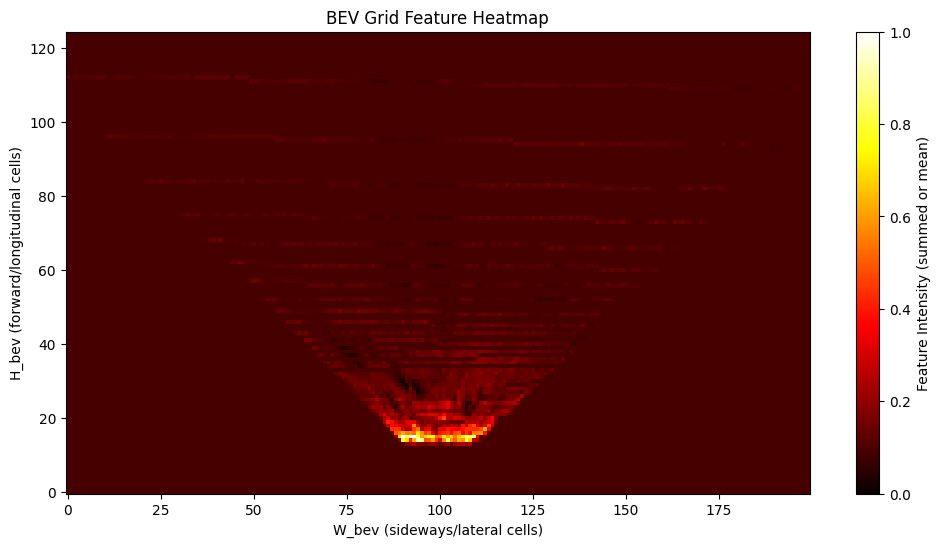

In [47]:
import matplotlib.pyplot as plt
import torch

# Suppose your BEV grid is named bev_grid, shape: [B, C, H_bev, W_bev]
# If you followed your previous code, it's likely [1, 256, 125, 200]

# Remove batch dimension (if present)
bev_img = bev_grid[0]  # shape: [C, H_bev, W_bev]

# Collapse feature channels: sum or mean
# bev_heat = bev_img.sum(dim=0)   # shape: [H_bev, W_bev]
# OR for mean:
bev_heat = bev_img.mean(dim=0)

# Optional: Normalize for display (0 to 1)
bev_heat = bev_heat.cpu().numpy()
bev_heat = (bev_heat - bev_heat.min()) / (bev_heat.max() - bev_heat.min() + 1e-8)

plt.figure(figsize=(12, 6))
plt.imshow(bev_heat, cmap='hot', aspect='auto', origin='lower')
plt.colorbar(label="Feature Intensity (summed or mean)")
plt.title("BEV Grid Feature Heatmap")
plt.xlabel("W_bev (sideways/lateral cells)")
plt.ylabel("H_bev (forward/longitudinal cells)")
plt.show()

In [52]:
#!/usr/bin/env python3
"""
nuScenes CAM->BEV projection (organized rewrite)

- Loads sample_data.json and finds the entry for a given sample_token & camera.
- Uses nuscenes_infos_temporal_val.pkl to fetch intrinsics/extrinsics.
- Loads an FPN feature map (e.g., P2) for that camera + sample.
- Computes ground-plane intersections and splats features into a BEV grid.

Author: you :)
"""

from __future__ import annotations

import os
import json
import pickle
import argparse
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import torch
from pyquaternion import Quaternion


# ------------------------------- Data Models -------------------------------- #

@dataclass
class NuScenesPaths:
    sample_data_json_path: str
    infos_pkl_path: str
    camera_feat_dir: str  # directory containing <sample_token>_lvl{fpn}.pt files


@dataclass
class CameraCalib:
    K: np.ndarray      # (3, 3)
    R: np.ndarray      # (3, 3) sensor->ego rotation
    T: np.ndarray      # (3,)   sensor->ego translation


@dataclass
class BEVSpec:
    x_min: float = 0.0
    x_max: float = 50.0
    cell_x: float = 0.4  # meters per cell (forward)
    y_min: float = -25.0
    y_max: float = 25.0
    cell_y: float = 0.25  # meters per cell (lateral)

    @property
    def H(self) -> int:
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self) -> int:
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))


# ------------------------------- I/O Helpers -------------------------------- #

def load_json(path: str) -> Any:
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Missing file: {path}")
    with open(path, "r") as f:
        return json.load(f)


def load_pickle(path: str) -> Any:
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Missing file: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)


def torch_load(path: str) -> Any:
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return torch.load(path, map_location="cpu")


# ----------------------------- nuScenes Queries ------------------------------ #

def find_entries_for_sample_token(
    sample_data: List[Dict[str, Any]],
    sample_token: str
) -> List[Dict[str, Any]]:
    """Return all sample_data entries matching a sample_token."""
    return [e for e in sample_data if e.get("sample_token") == sample_token]


def pick_camera_entry(
    entries: List[Dict[str, Any]],
    camera_name: str
) -> Optional[Dict[str, Any]]:
    """
    Heuristic: choose the first entry whose filename contains the camera_name
    (e.g., 'CAM_FRONT' in filename).
    """
    for e in entries:
        if camera_name in e.get("filename", ""):
            return e
    return None


def find_cam_info_by_sample_data_token(
    infos: List[Dict[str, Any]],
    camera_name: str,
    sample_data_token: str
) -> Tuple[int, Dict[str, Any]]:
    """
    Scan infos[] for the entry whose cams[camera_name]['sample_data_token'] matches.
    Returns (index, sample_dict).
    """
    for idx, sample in enumerate(infos):
        cam = sample["cams"].get(camera_name)
        if cam and cam.get("sample_data_token") == sample_data_token:
            return idx, sample
    raise KeyError(
        f"sample_data_token {sample_data_token} not found for camera {camera_name}."
    )


def extract_calibration(cam_info: Dict[str, Any]) -> CameraCalib:
    """Build intrinsics/extrinsics from a cam_info dict."""
    K = np.array(cam_info["cam_intrinsic"], dtype=np.float64)  # (3,3)
    R = Quaternion(cam_info["sensor2ego_rotation"]).rotation_matrix  # (3,3)
    T = np.array(cam_info["sensor2ego_translation"], dtype=np.float64)  # (3,)
    return CameraCalib(K=K, R=R, T=T)


# ----------------------------- Feature Loading ------------------------------- #

def feature_path(camera_dir: str, sample_token: str, fpn_level: int) -> str:
    """Return expected path to a feature file named '<sample_token>_lvl{fpn}.pt'."""
    return os.path.join(camera_dir, f"{sample_token}_lvl{fpn_level}.pt")


def load_fpn_feature(
    camera_dir: str,
    sample_token: str,
    fpn_level: int
) -> Tuple[torch.Tensor, Dict[str, Any]]:
    """
    Load a torch file containing dict with keys: 'feat' [C,Hf,Wf] or [B,C,Hf,Wf], 'img_shape', etc.
    Returns (feat[B,C,Hf,Wf], meta_dict).
    """
    path = feature_path(camera_dir, sample_token, fpn_level)
    blob = torch_load(path)

    feat = blob["feat"]
    if feat.ndim == 3:
        feat = feat.unsqueeze(0)  # [1,C,Hf,Wf]
    if feat.ndim != 4:
        raise ValueError(f"Unexpected feat shape {tuple(feat.shape)} in {path}")

    return feat, blob


# --------------------------- Geometry & Projection --------------------------- #

# def pixel_centers(Hf: int, Wf: int, stride: int) -> Tuple[torch.Tensor, torch.Tensor]:
#     """
#     Compute (U,V) pixel centers for a downsampled feature map with 'stride' w.r.t. the raw image.
#     Returns U,V of shape [Hf, Wf].
#     """
#     j = torch.arange(Wf, dtype=torch.float32) + 0.5  # width idx
#     i = torch.arange(Hf, dtype=torch.float32) + 0.5  # height idx
#     u = j * stride
#     v = i * stride
#     U, V = torch.meshgrid(u, v, indexing="xy")
#     U = U.t().contiguous()
#     V = V.t().contiguous()
#     return U, V
def pixel_centers_from_meta(Hf: int, Wf: int, img_h: int, img_w: int):
    """
    Compute (U,V) pixel centers for a feature map [Hf,Wf] aligned to an image [img_h,img_w],
    using per-axis strides inferred from sizes: stride_v = img_h/Hf, stride_u = img_w/Wf.
    Returns U,V of shape [Hf, Wf].
    """
    stride_v = float(img_h) / float(Hf)  # vertical (rows)
    stride_u = float(img_w) / float(Wf)  # horizontal (cols)

    j = torch.arange(Wf, dtype=torch.float32) + 0.5  # 0..Wf-1
    i = torch.arange(Hf, dtype=torch.float32) + 0.5  # 0..Hf-1

    u = j * stride_u
    v = i * stride_v

    U, V = torch.meshgrid(u, v, indexing="xy")
    U = U.t().contiguous()  # [Hf,Wf]
    V = V.t().contiguous()
    return U, V


def backproject_to_ground(
    U: torch.Tensor,
    V: torch.Tensor,
    calib: CameraCalib
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Backproject pixel centers to rays, transform to ego, and intersect z=0 plane.

    Returns:
      ix_float, iy_float: floating BEV coordinates (not yet discretized)
      mask_valid: boolean mask where intersection is valid (s>0 & dir_z!=0)
    """
    Hf, Wf = U.shape
    uv1 = np.stack(
        [U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf * Wf, dtype=np.float32)],
        axis=0
    )  # [3, N]

    K_inv = np.linalg.inv(calib.K)
    rays_cam = K_inv @ uv1      
    rays_cam[1:3, :] *= -1  # [3, N]
    rays_ego = calib.R @ rays_cam            # [3, N]

    dir_z = rays_ego[2, :]
    eps = 1e-6
    valid_dir = np.abs(dir_z) > eps

    cam_z = calib.T[2]
    s = np.zeros_like(dir_z, dtype=np.float64)
    s[valid_dir] = -cam_z / dir_z[valid_dir]

    mask_valid = valid_dir & (s > 0.0)

    Xg = calib.T[0] + s * rays_ego[0, :]
    Yg = calib.T[1] + s * rays_ego[1, :]

    return Xg, Yg, mask_valid


def xy_to_bev_indices(
    Xg: np.ndarray,
    Yg: np.ndarray,
    valid: np.ndarray,
    spec: BEVSpec
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert ego-frame ground points (Xg,Yg) to BEV integer indices.
    Returns (ix, iy, mask_kept).
    """
    ix = ((Xg - spec.x_min) / spec.cell_x).astype(np.int64)
    iy = ((Yg - spec.y_min) / spec.cell_y).astype(np.int64)

    in_bounds = (
        (ix >= 0) & (ix < spec.H) &
        (iy >= 0) & (iy < spec.W)
    )
    keep = valid & in_bounds
    return ix, iy, keep


def splat_features_to_bev(
    cam_feat: torch.Tensor,   # [B,C,Hf,Wf]
    ix: np.ndarray,
    iy: np.ndarray,
    keep: np.ndarray,
    spec: BEVSpec
) -> torch.Tensor:
    """
    Accumulate features into BEV with scatter_add (sum pooling).
    Returns bev_grid [B,C,H_bev,W_bev].
    """
    B, C, Hf, Wf = cam_feat.shape
    N = Hf * Wf

    bev_grid = torch.zeros((B, C, spec.H, spec.W), dtype=cam_feat.dtype)

    if keep.sum() == 0:
        return bev_grid

    # Flatten spatial dims
    feat_flat = cam_feat.reshape(B, C, N)  # [B,C,N]

    # Valid linear BEV indices
    ix_v = torch.from_numpy(ix[keep])                  # [Nv]
    iy_v = torch.from_numpy(iy[keep])                  # [Nv]
    lin_v = (ix_v * spec.W + iy_v).long()              # [Nv]

    # Prepare scatter targets
    bev_flat = bev_grid.view(B, C, spec.H * spec.W)    # [B,C,HW]
    mask_idx = torch.from_numpy(np.nonzero(keep)[0]).long()  # [Nv]

    # Gather valid features [B,C,Nv]
    src = feat_flat.index_select(dim=2, index=mask_idx)

    # Expand indices to [C,Nv] per-batch and scatter-add
    idx = lin_v.unsqueeze(0).expand(C, -1)  # [C,Nv]

    for b in range(B):
        bev_flat[b].scatter_add_(dim=1, index=idx, src=src[b])

    return bev_grid


# ---------------------------------- Main ------------------------------------ #

def run_pipeline(
    paths: NuScenesPaths,
    target_sample_token: str,
    camera_name: str = "CAM_FRONT",
    fpn_level: int = 0,
    stride_p2: int = 4,
    bev_spec: Optional[BEVSpec] = None,
) -> Dict[str, Any]:
    """
    Full end-to-end pipeline. Returns dictionary with useful artifacts.
    """
    bev_spec = bev_spec or BEVSpec()

    # --- Load/locate entries ---
    sample_data = load_json(paths.sample_data_json_path)
    entries = find_entries_for_sample_token(sample_data, target_sample_token)
    if not entries:
        raise KeyError(f"No entries found for sample_token={target_sample_token}")

    cam_entry = pick_camera_entry(entries, camera_name)
    if cam_entry is None:
        raise KeyError(f"No entry for camera {camera_name} within sample_token={target_sample_token}")

    target_token = cam_entry["token"]

    # --- Load infos and fetch cam_info ---
    infos_blob = load_pickle(paths.infos_pkl_path)
    infos = infos_blob["infos"]
    idx, sample = find_cam_info_by_sample_data_token(infos, camera_name, target_token)
    cam_info = sample["cams"][camera_name]

    # --- Calibration ---
    calib = extract_calibration(cam_info)

    # --- Feature map ---
    feat, feat_meta = load_fpn_feature(paths.camera_feat_dir, target_sample_token, fpn_level)
    B, C, Hf, Wf = feat.shape

    # --- Pixel centers & backproject ---
    U, V = pixel_centers(Hf, Wf, stride=stride_p2)
    Xg, Yg, valid = backproject_to_ground(U, V, calib)

    # --- Discretize to BEV & splat ---
    ix, iy, keep = xy_to_bev_indices(Xg, Yg, valid, bev_spec)
    bev = splat_features_to_bev(feat, ix, iy, keep, bev_spec)

    # --- Debug prints (optional) ---
    print(f"Found sample at infos[{idx}] for {camera_name}.")
    print("Camera Intrinsic (K):\n", calib.K)
    print("Camera->ego rotation (R):\n", calib.R)
    print("Camera->ego translation (T):\n", calib.T)
    print(f"Input feat shape: {tuple(feat.shape)}  (img_shape meta: {feat_meta.get('img_shape')})")
    print(f"BEV grid: {bev_spec.H} x {bev_spec.W} (cell {bev_spec.cell_x}m x {bev_spec.cell_y}m)")
    print("X_ground min/max:", float(np.min(Xg)), float(np.max(Xg)))
    print("Y_ground min/max:", float(np.min(Yg)), float(np.max(Yg)))
    print("Valid projected pixels:", int(keep.sum()))
    print("BEV tensor shape:", tuple(bev.shape))

    return {
        "cam_entry": cam_entry,
        "cam_info": cam_info,
        "calib": calib,
        "feat": feat,                # [B,C,Hf,Wf]
        "feat_meta": feat_meta,
        "bev": bev,                  # [B,C,H_bev,W_bev]
        "bev_spec": bev_spec,
        "keep_mask": keep,
        "indices": (ix, iy),
    }


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(description="nuScenes CAM->BEV projection pipeline")
    p.add_argument("--sample_data_json", type=str,
                   default="/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json")
    p.add_argument("--infos_pkl", type=str,
                   default="/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl")
    p.add_argument("--camera_feat_dir", type=str,
                   default="/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT")
    p.add_argument("--sample_token", type=str,
                   default="fd8420396768425eabec9bdddf7e64b6")
    p.add_argument("--camera_name", type=str, default="CAM_FRONT")
    p.add_argument("--fpn_level", type=int, default=0)
    p.add_argument("--stride", type=int, default=4, help="FPN stride for this level (e.g., P2=4)")
    # BEV spec
    p.add_argument("--x_min", type=float, default=0.0)
    p.add_argument("--x_max", type=float, default=50.0)
    p.add_argument("--cell_x", type=float, default=0.4)
    p.add_argument("--y_min", type=float, default=-25.0)
    p.add_argument("--y_max", type=float, default=25.0)
    p.add_argument("--cell_y", type=float, default=0.25)
    return p.parse_args()


# def main():
#     args = parse_args()

#     paths = NuScenesPaths(
#         sample_data_json_path=args.sample_data_json,
#         infos_pkl_path=args.infos_pkl,
#         camera_feat_dir=args.camera_feat_dir,
#     )

#     bev_spec = BEVSpec(
#         x_min=args.x_min, x_max=args.x_max, cell_x=args.cell_x,
#         y_min=args.y_min, y_max=args.y_max, cell_y=args.cell_y
#     )

#     _ = run_pipeline(
#         paths=paths,
#         target_sample_token=args.sample_token,
#         camera_name=args.camera_name,
#         fpn_level=args.fpn_level,
#         stride_p2=args.stride,
#         bev_spec=bev_spec,
#     )



if __name__ == "__main__":
    import sys
    # If running inside Jupyter, bypass argparse
    if "ipykernel_launcher" in sys.argv[0]:
        from types import SimpleNamespace
        args = SimpleNamespace(
            sample_data_json="/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json",
            infos_pkl="/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl",
            camera_feat_dir="/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT",
            sample_token="fd8420396768425eabec9bdddf7e64b6",
            camera_name="CAM_FRONT",
            fpn_level=0,
            stride=8,
            # stride=4,
            x_min=0.0, x_max=50.0, cell_x=0.4,
            y_min=-25.0, y_max=25.0, cell_y=0.25,
        )
    else:
        args = parse_args()

    paths = NuScenesPaths(
        sample_data_json_path=args.sample_data_json,
        infos_pkl_path=args.infos_pkl,
        camera_feat_dir=args.camera_feat_dir,
    )
    bev_spec = BEVSpec(
        x_min=args.x_min, x_max=args.x_max, cell_x=args.cell_x,
        y_min=args.y_min, y_max=args.y_max, cell_y=args.cell_y
    )
    _ = run_pipeline(
        paths=paths,
        target_sample_token=args.sample_token,
        camera_name=args.camera_name,
        fpn_level=args.fpn_level,
        stride_p2=args.stride,
        bev_spec=bev_spec,
    )



if __name__ == "__main__":
    main()


Found sample at infos[0] for CAM_FRONT.
Camera Intrinsic (K):
 [[1.26641720e+03 0.00000000e+00 8.16267020e+02]
 [0.00000000e+00 1.26641720e+03 4.91507066e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Camera->ego rotation (R):
 [[ 5.68477868e-03 -5.63666773e-03  9.99967955e-01]
 [-9.99983517e-01 -8.37115272e-04  5.68014846e-03]
 [ 8.05071338e-04 -9.99983763e-01 -5.64133364e-03]]
Camera->ego translation (T):
 [1.70079119 0.01594563 1.51095764]
Input feat shape: (1, 256, 116, 200)  (img_shape meta: [(928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3)])
BEV grid: 125 x 200 (cell 0.4m x 0.25m)
X_ground min/max: -352000.819401767 256114.72295367037
Y_ground min/max: -125585.33396342953 94623.44417292664
Valid projected pixels: 0
BEV tensor shape: (1, 256, 125, 200)


usage: ipykernel_launcher.py [-h] [--sample_data_json SAMPLE_DATA_JSON]
                             [--infos_pkl INFOS_PKL]
                             [--camera_feat_dir CAMERA_FEAT_DIR]
                             [--sample_token SAMPLE_TOKEN]
                             [--camera_name CAMERA_NAME]
                             [--fpn_level FPN_LEVEL] [--stride STRIDE]
                             [--x_min X_MIN] [--x_max X_MAX] [--cell_x CELL_X]
                             [--y_min Y_MIN] [--y_max Y_MAX] [--cell_y CELL_Y]
ipykernel_launcher.py: error: unrecognized arguments: -f /home/draiman/.local/share/jupyter/runtime/kernel-378ed0d5-5b99-4870-8feb-da4e4bd809e6.json


SystemExit: 2

Found 1982 LiDAR feature files.
Example files: ['/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/000681a060c04755a1537cf83b53ba57.pt', '/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/000868a72138448191b4092f75ed7776.pt', '/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/005d3e821c4e4e0ab03f1ea1dcbf9cc8.pt']
Using LiDAR BEV feature file: /home/draiman/Desktop/Datasets_nuscenes/validation/lidar/000681a060c04755a1537cf83b53ba57.pt
LiDAR BEV shape: torch.Size([1, 256, 90, 90])


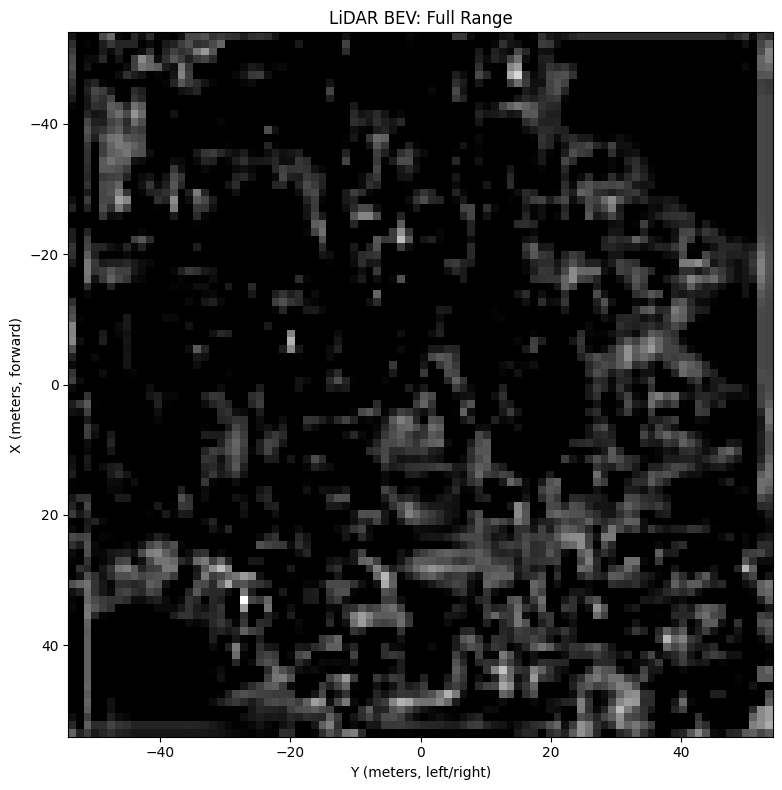

In [48]:
import glob

lidar_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar"
all_lidar_files = sorted(glob.glob(f"{lidar_dir}/*.pt"))
print(f"Found {len(all_lidar_files)} LiDAR feature files.")
print("Example files:", all_lidar_files[:3])

# Pick one file for testing
lidar_feat_path = all_lidar_files[0]  # or another index you want
print("Using LiDAR BEV feature file:", lidar_feat_path)

import torch

lidar_feat_path = '/home/draiman/Desktop/Datasets_nuscenes/validation/lidar/000681a060c04755a1537cf83b53ba57.pt'
d = torch.load(lidar_feat_path, map_location='cpu')
lidar_feat = d['feat']  # [B, C, H, W] or [C, H, W]
if lidar_feat.ndim == 3:
    lidar_feat = lidar_feat.unsqueeze(0)
B, C, H_bev, W_bev = lidar_feat.shape
print("LiDAR BEV shape:", lidar_feat.shape)

# Usually from CenterPoint config
pc_range = [-54, -54, -5, 54, 54, 3]   # [x_min, y_min, z_min, x_max, y_max, z_max]
x_min, y_min, _, x_max, y_max, _ = pc_range

bev_x = np.linspace(x_min, x_max, H_bev, endpoint=False)  # [H_bev]
bev_y = np.linspace(y_min, y_max, W_bev, endpoint=False)  # [W_bev]
X_bev, Y_bev = np.meshgrid(bev_x, bev_y, indexing='ij')   # [H_bev, W_bev]

import matplotlib.pyplot as plt

bev_img = lidar_feat[0, 0].cpu().numpy()  # show first channel, or sum for all

plt.figure(figsize=(8,8))
plt.imshow(bev_img, cmap='gray', extent=[y_min, y_max, x_max, x_min])
plt.xlabel("Y (meters, left/right)")
plt.ylabel("X (meters, forward)")
plt.title("LiDAR BEV: Full Range")
plt.tight_layout()
plt.show()


LiDAR projected onto camera BEV grid: torch.Size([1, 256, 125, 200])


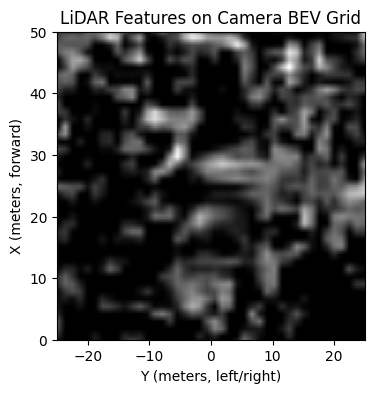

In [49]:

import torch
import torch.nn.functional as F
import numpy as np

# LiDAR feature from CenterPoint backbone
# lidar_feat: [1, 256, 90, 90]
B, C, Hs, Ws = lidar_feat.shape

# ---- LiDAR BEV world bounds (from your config) ----
# pc_range = [x_min, y_min, z_min, x_max, y_max, z_max]
x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-54, -54, -5, 54, 54, 3]

# ---- Target (camera BEV) bounds ----
x_min, x_max = 0.0, 50.0      # forward 0–50 m
y_min, y_max = -25.0, 25.0    # left/right −25–25 m
H_cam, W_cam = 125, 200       # (cell_x=0.4, cell_y=0.25)

# ---- Build sampling grid in world coordinates ----
cell_x = (x_max - x_min) / H_cam
cell_y = (y_max - y_min) / W_cam
xs = x_min + (torch.arange(H_cam, dtype=torch.float32) + 0.5) * cell_x
ys = y_min + (torch.arange(W_cam, dtype=torch.float32) + 0.5) * cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')  # [H_cam, W_cam]

# ---- Map (X,Y) → LiDAR BEV normalized coords ----
grid_x = 2.0 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1.0  # corresponds to W axis
grid_y = 2.0 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1.0  # corresponds to H axis
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)   # [1, H_cam, W_cam, 2]

# ---- Bilinear resample ----
lidar_on_cam = F.grid_sample(
    lidar_feat, grid, mode='bilinear', padding_mode='zeros', align_corners=True
)  # [1, 256, 125, 200]

print("LiDAR projected onto camera BEV grid:", lidar_on_cam.shape)

# ---- Optional quick visualization ----
import matplotlib.pyplot as plt
bev_img = lidar_on_cam[0, 0].cpu().numpy()
plt.figure(figsize=(8,4))
plt.imshow(bev_img, cmap='gray', origin='lower', extent=[y_min, y_max, x_min, x_max])
plt.xlabel("Y (meters, left/right)")
plt.ylabel("X (meters, forward)")
plt.title("LiDAR Features on Camera BEV Grid")
plt.show()


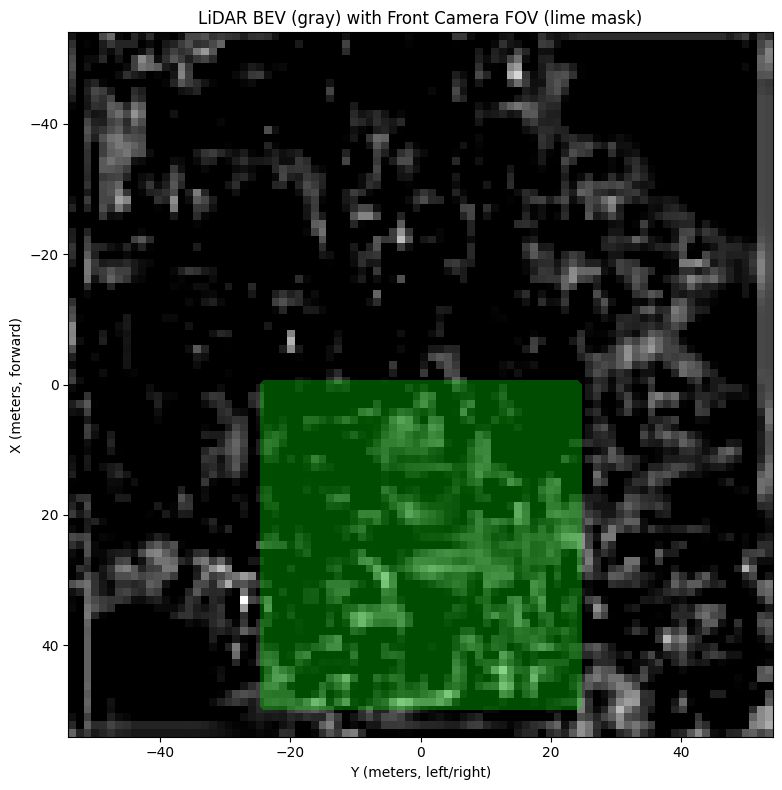

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- LiDAR BEV setup (already loaded) ---
lidar_bev = lidar_feat[0, 0].cpu().numpy()  # first channel just for visualization
H_bev, W_bev = lidar_bev.shape
x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-54, -54, -5, 54, 54, 3]

# Build meshgrid of LiDAR BEV coordinates (same as visualization before)
bev_x = np.linspace(x_min_l, x_max_l, H_bev, endpoint=False)
bev_y = np.linspace(y_min_l, y_max_l, W_bev, endpoint=False)
X_bev, Y_bev = np.meshgrid(bev_x, bev_y, indexing='ij')  # [H_bev, W_bev]

# --- Define front-camera BEV bounds ---
x_min, x_max = 0.0, 50.0      # forward range (m)
y_min, y_max = -25.0, 25.0    # lateral range (m)

# --- Create mask where LiDAR BEV cells fall within camera BEV bounds ---
cam_mask = (
    (X_bev >= x_min) & (X_bev <= x_max) &
    (Y_bev >= y_min) & (Y_bev <= y_max)
).astype(float)

# --- Plot LiDAR BEV with camera mask overlay ---
plt.figure(figsize=(8,8))
plt.imshow(lidar_bev, cmap='gray', extent=[y_min_l, y_max_l, x_max_l, x_min_l])
plt.contourf(Y_bev, X_bev, cam_mask, levels=[0.5, 1], colors='lime', alpha=0.3)
plt.xlabel("Y (meters, left/right)")
plt.ylabel("X (meters, forward)")
plt.title("LiDAR BEV (gray) with Front Camera FOV (lime mask)")
plt.tight_layout()
plt.show()


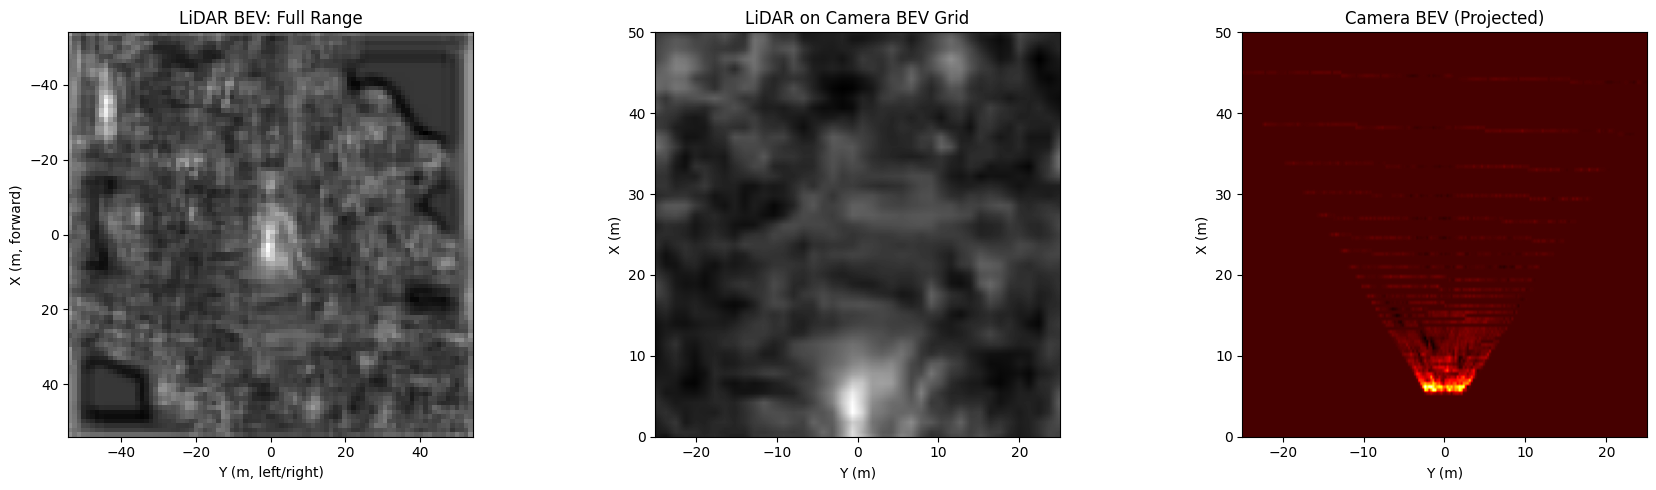

In [51]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- Inputs expected from your pipeline ---
# lidar_feat:   [B, C, 90, 90]           # full 360° LiDAR BEV features
# lidar_on_cam: [B, C, 125, 200]         # LiDAR features resampled to camera BEV grid
# bev_grid:     [B, C, 125, 200]         # camera BEV features (your projection result)

# World bounds you used:
x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-54, -54, -5, 54, 54, 3]  # LiDAR
x_min, x_max = 0.0, 50.0
y_min, y_max = -25.0, 25.0

# --- Collapse channels for visualization (sum or mean) ---
def to_img(t):  # t: torch tensor [B, C, H, W]
    img = t[0].mean(dim=0).detach().cpu().numpy()  # or .sum(dim=0)
    # normalize to [0,1] for display
    m, M = img.min(), img.max()
    return (img - m) / (M - m + 1e-8)

lidar_full_img = to_img(lidar_feat)      # [90, 90]
lidar_cam_img  = to_img(lidar_on_cam)    # [125, 200]
cam_bev_img    = to_img(bev_grid)        # [125, 200]

# --- Plot ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# (1) LiDAR full range (360°)
axs[0].imshow(lidar_full_img, cmap='gray',
              extent=[y_min_l, y_max_l, x_max_l, x_min_l])  # origin=upper by extent
axs[0].set_title("LiDAR BEV: Full Range")
axs[0].set_xlabel("Y (m, left/right)")
axs[0].set_ylabel("X (m, forward)")

# (2) LiDAR on camera BEV grid (front-only window)
axs[1].imshow(lidar_cam_img, cmap='gray', origin='lower',
              extent=[y_min, y_max, x_min, x_max])
axs[1].set_title("LiDAR on Camera BEV Grid")
axs[1].set_xlabel("Y (m)")
axs[1].set_ylabel("X (m)")

# (3) Camera BEV (projected features)
axs[2].imshow(cam_bev_img, cmap='hot', origin='lower',
              extent=[y_min, y_max, x_min, x_max])
axs[2].set_title("Camera BEV (Projected)")
axs[2].set_xlabel("Y (m)")
axs[2].set_ylabel("X (m)")

plt.tight_layout()
plt.show()
